# IAT 461 Final Project
## White Sturgeon Monitoring Strategy: EDA, Classification, and Monitoring Priorities

**Name:** `Kayne Hoy`  
**SFU ID:** `301543404`  
**Date:** `August 11, 2026`

---

This notebook evaluates three monitoring strategies using the Fraser River drainage White Sturgeon mark-recapture PIT tag dataset. I first clean and restructure the historical capture records, then use exploratory analysis to compare the strategy options. After selecting the most defensible option, I build and evaluate classification models for large mature encounters and translate the results into practical monitoring priorities.

The main management question is not how many White Sturgeon exist in each location. The question is where and when the historical capture records show stronger associations with large mature fish, while being clear about the limits of a dataset that does not contain survey effort.

## Project Overview and Technique Selection

The client is deciding how to use a limited monitoring budget. Option A would distribute monitoring more evenly across river reaches. Option B would focus on hatchery-released fish and the places where those fish are encountered. Option C would focus on locations and conditions that are more strongly associated with large mature White Sturgeon.

I treat Phase 1 as exploratory pattern discovery rather than a supervised modeling problem. The purpose is to compare distributions, missingness, capture concentration, hatchery information, fish size, and river locations before choosing a strategy. Phase 2 is a supervised binary classification problem because the proposal defines a clear outcome: whether fork length is at least 150 cm.

I first observe and clean the data, then engineer useful location and time features, and finally fit models that can classify the large mature outcome. I keep the stakeholder decision in view throughout the notebook. The final result should identify candidate monitoring priorities that a program manager can understand and investigate further, rather than only reporting model scores.


## Setup

I import a small set of familiar libraries for data loading, cleaning, tables, and visualization. I keep the code direct and use pandas operations so that each step can be inspected separately.


In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


# Color list I want to use
BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
RED = "#E45756"
PURPLE = "#B279A2"
GRAY = "#9D9D9D"



---

# 1. Data Loading and Documentation

## Data source

The dataset comes from the Province of British Columbia Data Catalogue: **White Sturgeon - Fraser River Drainage Mark-Recapture PIT Tag Data**.

Source link: https://catalogue.data.gov.bc.ca/dataset/white-sturgeon-fraser-river-drainage-mark-recapture-pit-tag-data

The attached catalogue PDF explains that the data were collected by government biologists and partner organizations, including First Nations and fisheries organizations. It also states that the data should be used with caution because records may not be verified and may change in future versions. The documented data lineage covers May 1991 to December 2020, which matches the date range that I later observe in the CSV file.



## Load the CSV file

I first load the full file without removing any rows. I rename the columns to simple snake-case names because this makes the later code easier to read. I preserve the original data values at this stage.


In [7]:
DATA_PATH = "sturgeon-pit-tag-dat.csv"
raw_df = pd.read_csv(DATA_PATH, low_memory=False)

raw_df = raw_df.rename(columns={
    "FishID": "fish_id",
    "Tag number": "tag_number",
    "Tag type": "tag_type",
    "Year class": "year_class",
    "Confirmed hatchery-release?": "hatchery_status",
    "Capture date": "capture_date",
    "Fork length": "fork_length",
    "Girth": "girth",
    "Waterbody": "waterbody",
    "Release date": "release_date",
    "RKM_Round": "rkm_round"
})

print(f"Loaded file: {DATA_PATH}")
print(f"Dataset shape: {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns")
display(raw_df.head(5))


Loaded file: sturgeon-pit-tag-dat.csv
Dataset shape: 224,134 rows and 11 columns


,fish_id,tag_number,tag_type,year_class,hatchery_status,capture_date,fork_length,girth,waterbody,release_date,rkm_round
0,1.00,88,Floy,NaN,NaN,2000-07-16,138.00,55.00,Nechako River,NaN,NaN
1,1.00,501F7A3051,PIT,NaN,NaN,2000-07-16,138.00,55.00,Nechako River,NaN,NaN
2,1.00,88,Floy,NaN,NaN,2001-10-12,147.50,58.00,Nechako River,NaN,120-130
3,1.00,501F7A3051,PIT,NaN,NaN,2001-10-12,147.50,58.00,Nechako River,NaN,120-130
4,1.00,501F7A3051,PIT,NaN,NaN,2006-05-09,165.00,68.00,Nechako River,NaN,130-140



The full file contains more than 224,000 rows, which agrees with the client proposal. One important issue is already visible in the first rows: the same fish and capture can appear more than once when the fish has more than one tag type. Therefore, I cannot assume that one CSV row always represents one separate encounter.



## Column dictionary

The source page does not provide a detailed field-by-field dictionary, so I document the fields using the column names, the proposal, and the values found in the file. I do not assign a biological meaning that is not supported by the supplied material.


In [8]:

column_dictionary = pd.DataFrame({
    "column": [
        "fish_id", "tag_number", "tag_type", "year_class", "hatchery_status",
        "capture_date", "fork_length", "girth", "waterbody", "release_date", "rkm_round"
    ],
    "meaning": [
        "Internal identifier used to connect records for the same fish",
        "Recorded tag serial number or tag label",
        "Type of tag, such as PIT, Floy, Acoustic, or Radio",
        "Recorded hatchery year class when available",
        "Explicit confirmation that a fish is hatchery-released; blank is not treated as wild",
        "Date of a recorded fish capture",
        "Fork length measurement in centimetres; Phase 2 uses 150 cm as the threshold",
        "Girth measurement supplied in the dataset",
        "Named river or lake where the record occurred",
        "Date of a hatchery release record",
        "Rounded 10-km river segment where the record occurred"
    ]
})

display(column_dictionary)


,column,meaning
0,fish_id,Internal identifier used to connect records fo...
1,tag_number,Recorded tag serial number or tag label
2,tag_type,"Type of tag, such as PIT, Floy, Acoustic, or R..."
3,year_class,Recorded hatchery year class when available
4,hatchery_status,Explicit confirmation that a fish is hatchery-...
5,capture_date,Date of a recorded fish capture
6,fork_length,Fork length measurement in centimetres; Phase ...
7,girth,Girth measurement supplied in the dataset
8,waterbody,Named river or lake where the record occurred
9,release_date,Date of a hatchery release record


## Understanding the Main Variables

Before cleaning the data, I want to clarify how I interpret some of the main variables because several of them are important throughout the analysis.

* `rkm_round` represents the rounded river-kilometre segment where a fish was recorded. Instead of giving an exact point, the dataset groups the capture location into a 10-kilometre range. For example, an RKM value of `120-130` means that the fish was recorded somewhere within that 10-kilometre segment. Therefore, I should not interpret RKM as an exact GPS location. I also need to consider `waterbody` together with RKM because the same RKM range can appear in different rivers or waterbodies and does not necessarily represent the same physical location.

* `waterbody` identifies the named river or lake where the record occurred. This is one of the most important location variables in the project. I use it together with `rkm_round` to create a more specific description of where a fish was encountered. For example, Fraser River RKM 140-150 and Harrison River RKM 0-10 represent two different monitoring locations.

* `fork_length` is the recorded fork length of the fish in centimetres. This is the main biological measurement used in this project because the client defines a large mature White Sturgeon as having a fork length of at least 150 cm. Later, I create the binary target variable `large_mature`, where a value of 1 represents a fish with fork length greater than or equal to 150 cm and 0 represents a fish below 150 cm.

* `girth` is another body-size measurement included in the dataset. Although girth can provide useful information about fish size, I do not use it as a predictor in the final classification model. Since the outcome I am trying to predict is already based directly on fish size, including another body-size measurement could make the prediction less useful for deciding where and when monitoring should occur.

* `capture_date` records when a fish was captured. I later use this variable to create `capture_year` and `capture_month`. These derived variables allow me to investigate whether large mature encounters are associated with particular periods of time. Month is especially useful when I compare seasonal patterns in the capture records.

* `fish_id` is the internal identifier that connects records belonging to the same fish. This is important because an individual fish can appear multiple times in the dataset. I use this identifier when constructing encounters and when separating the training and testing data so that records from the same fish do not appear in both groups.

* `tag_number` records the serial number or label of a tag, while `tag_type` identifies the type of tag used, such as PIT, Floy, Acoustic, or Radio. A fish can have more than one tag record for the same capture. Because of this, I do not assume that every row in the original CSV represents a separate fish encounter.

* `hatchery_status` provides explicit confirmation when a fish is identified as hatchery-released. A missing value does not necessarily mean that the fish is wild, so I avoid making that assumption. I create `hatchery_confirmed` as a simpler indicator that only identifies records where hatchery status is explicitly confirmed.

* `release_date` represents the date of a hatchery release record. Many rows with a release date do not represent a later capture encounter, so I separate release-only records from actual capture records before conducting the monitoring analysis.

* `year_class` contains the recorded hatchery year class when that information is available. However, this variable has a large amount of missing data, so I treat it cautiously and do not rely on it as a major variable in the final model.




## Initial data profile

The data cleaning is about checking data types, missingness, and unusual values before deciding how to clean a dataset. I create one profile table that shows the data type, number of missing values, missing percentage, and number of unique values for every column.


In [9]:

profile = pd.DataFrame({
    "data_type": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(1),
    "unique_values": raw_df.nunique(dropna=True)
}).sort_values("missing_percent", ascending=False)

display(profile)


,data_type,missing_count,missing_percent,unique_values
year_class,float64,209917,93.70,3
release_date,object,179158,79.90,59
hatchery_status,object,177219,79.10,1
girth,float64,49552,22.10,653
fork_length,float64,46945,20.90,1181
capture_date,object,44978,20.10,6446
tag_number,object,811,0.40,131080
rkm_round,object,524,0.20,91
fish_id,float64,0,0.00,130345
tag_type,object,0,0.00,4



The missingness is not evenly distributed. `year_class`, `release_date`, and `hatchery_status` are mostly blank, while `fork_length`, `girth`, and `capture_date` are missing for about one fifth of the rows. This pattern suggests that the file mixes different record types rather than containing random missing values. I investigate that structure before dropping or filling anything.



---

# 2. Data Cleaning and Encounter Construction

## Convert the date fields and separate record types

I convert both date columns to pandas datetime values. I then classify each row as a capture record, a release-only record, or a row with neither date. This step is important because release-only rows should not be counted as fish captures when I compare monitoring locations.


In [10]:

df = raw_df.copy()

df["capture_date"] = pd.to_datetime(df["capture_date"], errors="coerce")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["record_type"] = "Neither date"
df.loc[df["capture_date"].notna(), "record_type"] = "Capture"
df.loc[
    df["capture_date"].isna() & df["release_date"].notna(),
    "record_type"
] = "Release only"

record_type_summary = df["record_type"].value_counts().to_frame("row_count")
record_type_summary["percent"] = (
    record_type_summary["row_count"] / len(df) * 100
).round(1)

display(record_type_summary)

print("Capture date range:", df["capture_date"].min().date(), "to", df["capture_date"].max().date())
print("Release date range:", df["release_date"].min().date(), "to", df["release_date"].max().date())


,row_count,percent
record_type,,
Capture,179156,79.90
Release only,44976,20.10
Neither date,2,0.00


Capture date range: 1991-05-17 to 2020-12-30
Release date range: 2006-10-04 to 2020-06-19



About one fifth of the rows are release-only records. Most of these are hatchery release records from the Nechako River. I keep them in the original table for documentation, but I exclude them from the capture encounter analysis. This decision prevents the release program from being incorrectly counted as monitoring encounters.

There are only two rows with neither a capture date nor a release date. I do not use them because I cannot place them in the capture timeline or the release timeline.



## Parse the river-kilometre ranges

`rkm_round` is stored as a text range such as `120-130`. For grouped EDA, the original range is already useful as a category. For the future model, I also create the start, end, and midpoint of each range. This is a simple form of feature engineering because I convert one text field into ordered numeric information.


In [11]:

rkm_parts = df["rkm_round"].str.extract(r"(?P<rkm_start>\d+)-(?P<rkm_end>\d+)")

df["rkm_start"] = pd.to_numeric(rkm_parts["rkm_start"], errors="coerce")
df["rkm_end"] = pd.to_numeric(rkm_parts["rkm_end"], errors="coerce")
df["rkm_midpoint"] = (df["rkm_start"] + df["rkm_end"]) / 2

rkm_check = pd.DataFrame({
    "original_rkm_missing": df["rkm_round"].isna().sum(),
    "parsed_midpoint_missing": df["rkm_midpoint"].isna().sum()
}, index=["rows"])

display(rkm_check)
display(df[["rkm_round", "rkm_start", "rkm_end", "rkm_midpoint"]].drop_duplicates().head(12))


,original_rkm_missing,parsed_midpoint_missing
rows,524,524


,rkm_round,rkm_start,rkm_end,rkm_midpoint
0,NaN,NaN,NaN,NaN
2,120-130,120.00,130.00,125.00
4,130-140,130.00,140.00,135.00
6,110-120,110.00,120.00,115.00
22,90-100,90.00,100.00,95.00
59,100-110,100.00,110.00,105.00
64,60-70,60.00,70.00,65.00
137,0-10,0.00,10.00,5.00
138,950-960,950.00,960.00,955.00
148,860-870,860.00,870.00,865.00



All non-missing RKM values follow the same range format, so the midpoint conversion does not create extra missing values. I keep both forms because the category is easy to explain to the stakeholder, while the midpoint may be useful for a model that needs an ordered location feature.



## Sanity check the fork length values

A sanity check looks for values that are far outside the main distribution or conflict with the other records. I inspect the largest unique fork length values rather than immediately applying a general outlier rule. I do this because very large fish are the target of the project, so a standard IQR filter could incorrectly remove valid large fish.


In [12]:

largest_unique_lengths = (
    df["fork_length"]
    .dropna()
    .drop_duplicates()
    .sort_values(ascending=False)
    .head(25)
    .reset_index(drop=True)
    .to_frame("fork_length")
)

display(largest_unique_lengths)


,fork_length
0,"1,106.00"
1,"1,105.00"
2,"1,096.00"
3,"1,088.00"
4,"1,087.00"
5,"1,086.00"
6,"1,085.00"
7,"1,084.00"
8,"1,083.00"
9,"1,081.00"



The values from 1,074 to 1,106 are separated from the next largest value of 345 by a very large gap. Several of these rows occur on the same dates and locations as more realistic measurements for the same fish. This pattern looks like a data-entry problem rather than a valid extension of the distribution.

I set fork lengths above 400 to missing instead of deleting the full rows or guessing a corrected value. Only 23 raw rows meet this rule. I preserve valid large fish up to 345 cm and avoid inventing replacements for the questionable values.


In [13]:

df["fork_length_clean"] = df["fork_length"].where(df["fork_length"] <= 400)

fork_cleaning_summary = pd.DataFrame({
    "check": ["Raw non-missing fork lengths", "Values above 400 set to missing", "Clean non-missing fork lengths"],
    "row_count": [
        df["fork_length"].notna().sum(),
        (df["fork_length"] > 400).sum(),
        df["fork_length_clean"].notna().sum()
    ]
})

display(fork_cleaning_summary)


,check,row_count
0,Raw non-missing fork lengths,177189
1,Values above 400 set to missing,23
2,Clean non-missing fork lengths,177166



## Build one encounter-level table

The dataset can repeat one capture because a fish may have multiple tag types or multiple tag rows. The proposal also warns that the same fish can be captured on different dates. I need to handle these two situations differently.

I define one encounter as one fish on one capture date in one waterbody and one RKM segment. I combine repeated tag rows inside that encounter. If the repeated rows contain more than one distinct plausible fork length, I mark the fork length as missing because I cannot determine which measurement is correct. This keeps one encounter for the frequency analysis without forcing an uncertain size value into the Option C analysis.


In [14]:

capture_rows = df[df["capture_date"].notna()].copy()

capture_rows["fork_round"] = capture_rows["fork_length_clean"].round(1)
capture_rows["girth_round"] = capture_rows["girth"].round(1)
capture_rows["hatchery_confirmed"] = capture_rows["hatchery_status"].eq("Hatchery")

encounter_keys = ["fish_id", "capture_date", "waterbody", "rkm_round"]

encounters = (
    capture_rows.groupby(encounter_keys, dropna=False, as_index=False)
    .agg(
        fork_length=("fork_length_clean", "median"),
        fork_value_count=("fork_round", "nunique"),
        girth=("girth", "median"),
        girth_value_count=("girth_round", "nunique"),
        hatchery_confirmed=("hatchery_confirmed", "max"),
        year_class=("year_class", "first"),
        tag_rows=("tag_type", "size"),
        first_tag_type=("tag_type", "first")
    )
)

encounters["fork_conflict"] = encounters["fork_value_count"] > 1
encounters.loc[encounters["fork_conflict"], "fork_length"] = np.nan

encounters["capture_year"] = encounters["capture_date"].dt.year
encounters["capture_month"] = encounters["capture_date"].dt.month

rkm_parts_encounter = encounters["rkm_round"].str.extract(r"(?P<rkm_start>\d+)-(?P<rkm_end>\d+)")
encounters["rkm_start"] = pd.to_numeric(rkm_parts_encounter["rkm_start"], errors="coerce")
encounters["rkm_end"] = pd.to_numeric(rkm_parts_encounter["rkm_end"], errors="coerce")
encounters["rkm_midpoint"] = (encounters["rkm_start"] + encounters["rkm_end"]) / 2

cleaning_summary = pd.DataFrame({
    "stage": [
        "All CSV rows",
        "Rows with a capture date",
        "Encounter-level rows after combining repeated tag rows",
        "Encounter rows with usable fork length"
    ],
    "row_count": [
        len(df),
        len(capture_rows),
        len(encounters),
        encounters["fork_length"].notna().sum()
    ]
})

display(cleaning_summary)

print(f"Repeated tag rows combined: {len(capture_rows) - len(encounters):,}")
print(f"Encounters with conflicting fork length values: {encounters['fork_conflict'].sum():,}")


,stage,row_count
0,All CSV rows,224134
1,Rows with a capture date,179156
2,Encounter-level rows after combining repeated ...,176867
3,Encounter rows with usable fork length,174759


Repeated tag rows combined: 2,289
Encounters with conflicting fork length values: 152



The encounter table contains about 176,000 observations. Combining tag rows removes more than 2,000 repeated rows, while only a small number of encounters have conflicting plausible fork length measurements. I keep all encounters for location-frequency analysis, but I use only the size-complete encounters when I calculate the large mature class.

I do not fill missing fork length with an average or median because fork length defines the target. Imputing it would create artificial labels and could bias both the strategy comparison and the future classifier.



---

# 3. High-Level Dataset Overview

## Encounter counts, unique fish, and recaptures

One fish may appear in several encounters over time. I calculate the number of encounters per fish so I can understand how much repeated-measures structure exists in the data. This matters for Phase 2 because the same fish should not appear in both the training and test sets.


In [15]:

encounters_per_fish = encounters.groupby("fish_id").size()

high_level_overview = pd.DataFrame({
    "measure": [
        "Encounter rows",
        "Unique captured fish",
        "Fish with two or more encounters",
        "Share of fish with two or more encounters",
        "Median encounters per fish",
        "Maximum encounters for one fish"
    ],
    "value": [
        f"{len(encounters):,}",
        f"{encounters['fish_id'].nunique():,}",
        f"{(encounters_per_fish >= 2).sum():,}",
        f"{(encounters_per_fish >= 2).mean() * 100:.1f}%",
        f"{encounters_per_fish.median():.0f}",
        f"{encounters_per_fish.max():.0f}"
    ]
})

display(high_level_overview)
display(encounters_per_fish.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("encounters_per_fish"))


,measure,value
0,Encounter rows,"176,867"
1,Unique captured fish,"87,270"
2,Fish with two or more encounters,"38,922"
3,Share of fish with two or more encounters,44.6%
4,Median encounters per fish,1
5,Maximum encounters for one fish,70


,encounters_per_fish
count,"87,270.00"
mean,2.03
std,1.78
min,1.00
50%,1.00
75%,2.00
90%,4.00
95%,5.00
99%,9.00
max,70.00



Almost half of the captured fish have at least two recorded encounters. This confirms that the rows are not independent observations from completely different fish. For the final model, I will split the data by `fish_id` rather than using a simple random row split. This will test whether the model generalizes to fish that it has not already seen.



## Fork length distribution and the project threshold

The client defines a large mature size class as fork length greater than or equal to 150 cm. I visualize the cleaned length distribution and mark this threshold. A histogram is appropriate because I want to see the shape, spread, and balance of one continuous variable.


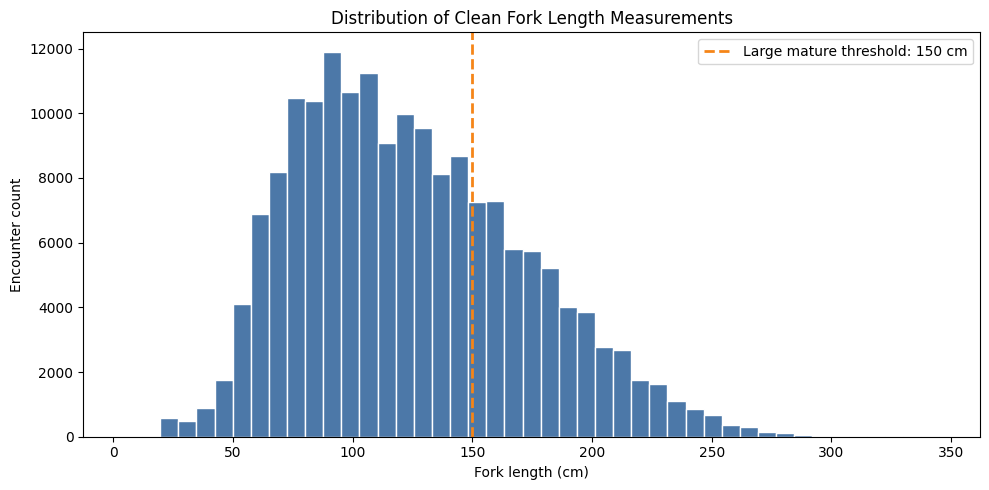

,class,encounters,percent
0,Below 150 cm,123928,70.90
1,At least 150 cm,50831,29.10


In [16]:

size_complete = encounters[encounters["fork_length"].notna()].copy()
size_complete["large_mature"] = size_complete["fork_length"] >= 150

plt.figure(figsize=(10, 5))
plt.hist(size_complete["fork_length"], bins=45, color=BLUE, edgecolor="white")
plt.axvline(150, color=ORANGE, linestyle="--", linewidth=2, label="Large mature threshold: 150 cm")
plt.xlabel("Fork length (cm)")
plt.ylabel("Encounter count")
plt.title("Distribution of Clean Fork Length Measurements")
plt.legend()
plt.tight_layout()
plt.show()

large_summary = pd.DataFrame({
    "class": ["Below 150 cm", "At least 150 cm"],
    "encounters": [
        (~size_complete["large_mature"]).sum(),
        size_complete["large_mature"].sum()
    ]
})
large_summary["percent"] = (
    large_summary["encounters"] / large_summary["encounters"].sum() * 100
).round(1)

display(large_summary)



The target class is not extremely rare. About 29% of the size-complete encounters meet the 150 cm threshold. This is enough to support classification, but it is still imbalanced because the smaller class is much larger. For this reason, I will not evaluate the final model with accuracy alone. Precision, recall, F1, and ROC-AUC will give a more complete view of performance.



## Capture records over time

I extract the capture year from the date, which follows the approach of creating useful features from timestamps. I plot encounter counts by year to check whether the amount of data is stable across the study period.


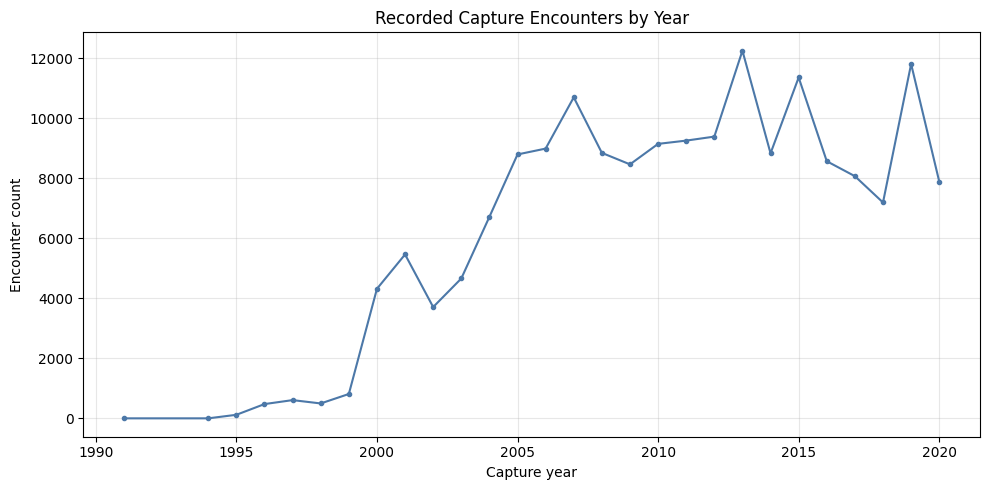

,capture_year,encounter_count,unique_fish
18,2011,9252,8467
19,2012,9385,8622
20,2013,12246,10959
21,2014,8828,7934
22,2015,11355,10057
23,2016,8565,7645
24,2017,8067,7281
25,2018,7191,6534
26,2019,11803,10468
27,2020,7889,7274


In [17]:

yearly_summary = (
    encounters.groupby("capture_year")
    .agg(
        encounter_count=("fish_id", "size"),
        unique_fish=("fish_id", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(yearly_summary["capture_year"], yearly_summary["encounter_count"], color=BLUE, marker="o", markersize=3)
plt.xlabel("Capture year")
plt.ylabel("Encounter count")
plt.title("Recorded Capture Encounters by Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(yearly_summary.tail(10))



The amount of recorded data changes substantially across years. The earliest years contain very few records, while later years contain thousands. This means that a location pattern may partly reflect changes in survey programs, tagging practices, or reporting over time. I will include time features in the model and examine a time-aware validation check in addition to the fish-level split.



---

# 4. Summary Tables for the Three Strategy Options

I create waterbody and waterbody-RKM summaries once so that the three options are compared from the same encounter-level dataset. I calculate the number of encounters, number of unique fish, number of size-complete encounters, median fork length, number of confirmed hatchery encounters, number of large mature encounters, and the observed large mature share.

The large mature share is a descriptive share of the recorded size-complete encounters. It is not a population estimate and it is not adjusted for survey effort.


In [18]:

encounters["large_mature"] = (encounters["fork_length"] >= 150).astype("Int64")
encounters.loc[encounters["fork_length"].isna(), "large_mature"] = pd.NA

waterbody_summary = (
    encounters.groupby("waterbody")
    .agg(
        encounters=("fish_id", "size"),
        unique_fish=("fish_id", "nunique"),
        fork_complete=("large_mature", "count"),
        median_fork_length=("fork_length", "median"),
        large_count=("large_mature", "sum"),
        confirmed_hatchery_count=("hatchery_confirmed", "sum"),
        missing_rkm=("rkm_round", lambda values: values.isna().sum())
    )
)

waterbody_summary["encounter_share_percent"] = (
    waterbody_summary["encounters"] / waterbody_summary["encounters"].sum() * 100
)
waterbody_summary["fork_complete_percent"] = (
    waterbody_summary["fork_complete"] / waterbody_summary["encounters"] * 100
)
waterbody_summary["large_share_percent"] = (
    waterbody_summary["large_count"] / waterbody_summary["fork_complete"] * 100
)

segment_summary = (
    encounters.groupby(["waterbody", "rkm_round"], dropna=False)
    .agg(
        encounters=("fish_id", "size"),
        unique_fish=("fish_id", "nunique"),
        fork_complete=("large_mature", "count"),
        median_fork_length=("fork_length", "median"),
        large_count=("large_mature", "sum"),
        confirmed_hatchery_count=("hatchery_confirmed", "sum")
    )
)

segment_summary["fork_complete_percent"] = (
    segment_summary["fork_complete"] / segment_summary["encounters"] * 100
)
segment_summary["large_share_percent"] = (
    segment_summary["large_count"] / segment_summary["fork_complete"] * 100
)

waterbody_display = waterbody_summary.sort_values("encounters", ascending=False).round(1)
display(waterbody_display)


,encounters,unique_fish,fork_complete,median_fork_length,large_count,confirmed_hatchery_count,missing_rkm,encounter_share_percent,fork_complete_percent,large_share_percent
waterbody,,,,,,,,,,
Fraser River,158571,81411,157731,115.00,42790,102,227,89.70,99.50,27.10
Harrison River,12792,6110,12725,155.00,7160,0,0,7.20,99.50,56.30
Nechako River,2749,2235,1556,75.10,522,1809,13,1.60,56.60,33.50
Pitt River,2644,2310,2636,100.00,307,2,0,1.50,99.70,11.60
Bowron River,40,39,40,90.50,5,1,0,0.00,100.00,12.50
Stuart Lake,27,25,27,198.00,26,0,27,0.00,100.00,96.30
Fraser Lake,19,19,19,72.20,4,13,19,0.00,100.00,21.10
Harrison Lake,14,14,14,170.50,10,0,0,0.00,100.00,71.40
Stuart River,6,6,6,156.50,4,0,2,0.00,100.00,66.70



---

# 5. Option A: Distribute Monitoring More Evenly

## Where are the recorded encounters concentrated?

I first compare encounter counts across waterbodies. A bar chart makes the size difference easy to see. I use encounter-level records rather than raw rows so that fish with multiple tags are not counted more than once during the same encounter.


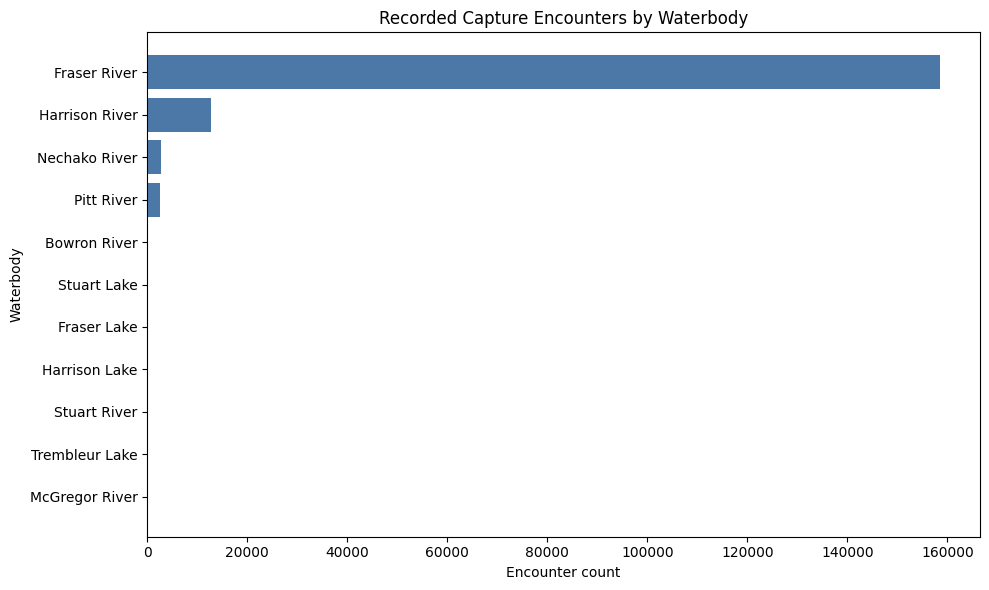

,encounters,unique_fish,encounter_share_percent
waterbody,,,
Fraser River,158571,81411,89.66
Harrison River,12792,6110,7.23
Nechako River,2749,2235,1.55
Pitt River,2644,2310,1.49
Bowron River,40,39,0.02
Stuart Lake,27,25,0.02
Fraser Lake,19,19,0.01
Harrison Lake,14,14,0.01
Stuart River,6,6,0.00


In [19]:

waterbody_counts = waterbody_summary.sort_values("encounters", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(waterbody_counts.index, waterbody_counts["encounters"], color=BLUE)
plt.xlabel("Encounter count")
plt.ylabel("Waterbody")
plt.title("Recorded Capture Encounters by Waterbody")
plt.tight_layout()
plt.show()

option_a_waterbody = waterbody_summary[
    ["encounters", "unique_fish", "encounter_share_percent"]
].sort_values("encounters", ascending=False).round(2)

display(option_a_waterbody)



The encounter records are highly concentrated in the Fraser River. Approximately 89.7% of the encounter-level records come from that waterbody, followed by the Harrison River at about 7.2%. Several lakes and smaller rivers have fewer than 50 encounters.

This confirms that the database is not evenly distributed across waterbodies. However, it does not show why the distribution is uneven. The dataset does not contain survey hours, number of nets, number of crews, unsuccessful surveys, or total monitoring cost. Therefore, I cannot separate monitoring effort from fish availability or reporting practices.



## Concentration within waterbody-RKM segments

I also inspect the individual waterbody-RKM combinations with the largest number of encounters. I keep the waterbody name attached to the RKM range because the same range label can exist in different rivers.


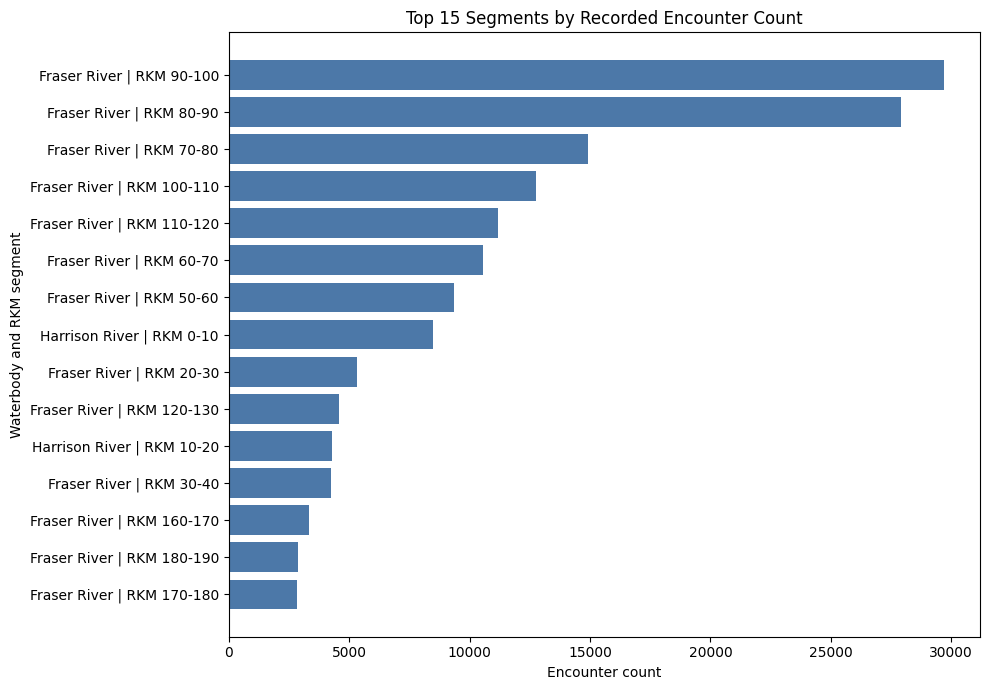

,waterbody,rkm_round,encounters,unique_fish,fork_complete
0,Fraser River,90-100,29708,20296,29574
1,Fraser River,80-90,27896,21439,27778
2,Fraser River,70-80,14918,12243,14874
3,Fraser River,100-110,12746,8773,12685
4,Fraser River,110-120,11188,7747,11152
5,Fraser River,60-70,10562,8693,10536
6,Fraser River,50-60,9345,7637,9111
7,Harrison River,0-10,8493,4613,8440
8,Fraser River,20-30,5309,4548,5295
9,Fraser River,120-130,4594,3480,4579


In [20]:

top_segments_by_encounters = (
    segment_summary.reset_index()
    .dropna(subset=["rkm_round"])
    .sort_values("encounters", ascending=False)
    .head(15)
    .copy()
)

top_segments_by_encounters["segment"] = (
    top_segments_by_encounters["waterbody"] + " | RKM " + top_segments_by_encounters["rkm_round"]
)

plot_a_segments = top_segments_by_encounters.sort_values("encounters", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_a_segments["segment"], plot_a_segments["encounters"], color=BLUE)
plt.xlabel("Encounter count")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top 15 Segments by Recorded Encounter Count")
plt.tight_layout()
plt.show()

display(
    top_segments_by_encounters[
        ["waterbody", "rkm_round", "encounters", "unique_fish", "fork_complete"]
    ].reset_index(drop=True)
)



The two largest segments are Fraser River RKM 90-100 and RKM 80-90. Together, they account for almost one third of all encounter-level records. This is strong evidence of concentration in the database, but it is not enough to conclude that monitoring should be redistributed evenly.

My current assessment is that Option A is only partially supported. The data can identify underrepresented and overrepresented segments, but it cannot evaluate the efficiency of current effort because the required effort denominator is missing. An even distribution could also reduce monitoring in locations where important fish are more frequently encountered.



---

# 6. Option B: Prioritize Confirmed Hatchery-Released Fish

## Coverage of the hatchery field

The hatchery column contains the value `Hatchery` or a blank. I treat the blank as unknown or not explicitly confirmed. I do not rename it as wild because the supplied data does not support that interpretation.

I compare release-only rows with captured encounters so that the large number of release records does not get mixed with recapture evidence.


,record_group,count
0,Release-only rows marked Hatchery,44976
1,Capture encounters explicitly confirmed as Hat...,1927
2,All capture encounters,176867


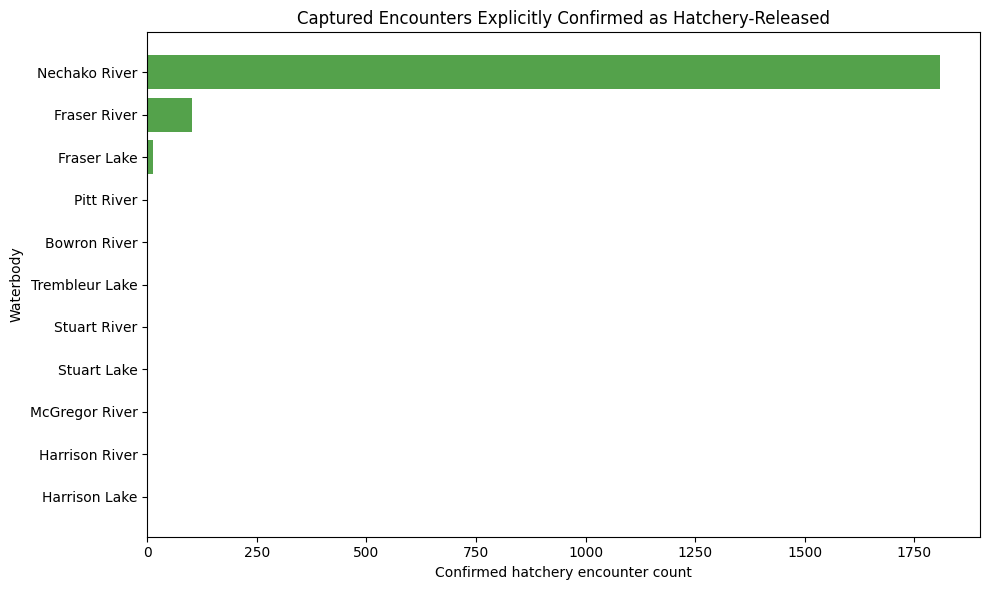

,encounters,confirmed_hatchery_count
waterbody,,
Nechako River,2749,1809
Fraser River,158571,102
Fraser Lake,19,13
Pitt River,2644,2
Bowron River,40,1
Harrison River,12792,0
Harrison Lake,14,0
McGregor River,2,0
Stuart Lake,27,0


In [21]:

hatchery_context = pd.DataFrame({
    "record_group": [
        "Release-only rows marked Hatchery",
        "Capture encounters explicitly confirmed as Hatchery",
        "All capture encounters"
    ],
    "count": [
        df.loc[df["record_type"].eq("Release only") & df["hatchery_status"].eq("Hatchery")].shape[0],
        encounters["hatchery_confirmed"].sum(),
        len(encounters)
    ]
})

display(hatchery_context)

hatchery_by_waterbody = (
    waterbody_summary[["encounters", "confirmed_hatchery_count"]]
    .sort_values("confirmed_hatchery_count", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(hatchery_by_waterbody.index, hatchery_by_waterbody["confirmed_hatchery_count"], color=GREEN)
plt.xlabel("Confirmed hatchery encounter count")
plt.ylabel("Waterbody")
plt.title("Captured Encounters Explicitly Confirmed as Hatchery-Released")
plt.tight_layout()
plt.show()

display(
    waterbody_summary[
        ["encounters", "confirmed_hatchery_count"]
    ].sort_values("confirmed_hatchery_count", ascending=False)
)



There are 1,927 encounter-level capture records explicitly confirmed as hatchery-released. About 94% of these confirmed hatchery encounters occur in the Nechako River. The Fraser River has only a small number of explicitly confirmed hatchery encounters compared with its very large total number of encounters.

This result identifies the Nechako River as the main area represented by the hatchery field. However, the field is one-sided and mostly blank. I can find confirmed hatchery fish, but I cannot reliably compare them with a clearly labelled wild group across the full drainage.



## RKM segments with confirmed hatchery encounters

I list the segments with the largest number of confirmed hatchery encounters. This shows whether the available hatchery information is concentrated within the Nechako River as well as across waterbodies.


In [22]:

top_hatchery_segments = (
    segment_summary.reset_index()
    .query("confirmed_hatchery_count > 0")
    .sort_values("confirmed_hatchery_count", ascending=False)
    .head(15)
)

display(
    top_hatchery_segments[
        [
            "waterbody", "rkm_round", "encounters",
            "confirmed_hatchery_count", "fork_complete", "large_count"
        ]
    ].reset_index(drop=True)
)


,waterbody,rkm_round,encounters,confirmed_hatchery_count,fork_complete,large_count
0,Nechako River,110-120,1155,618,935,297
1,Nechako River,120-130,735,545,283,103
2,Nechako River,130-140,442,340,157,77
3,Nechako River,100-110,211,192,51,7
4,Nechako River,190-200,57,55,11,0
5,Fraser River,760-770,21,15,21,2
6,Fraser River,680-690,21,14,21,0
7,Fraser River,550-560,280,13,276,121
8,Fraser Lake,NaN,19,13,19,4
9,Nechako River,160-170,13,13,0,0



The largest confirmed hatchery concentrations are Nechako River RKM 110-120, 120-130, and 130-140. This makes Option B understandable as a specialized hatchery-monitoring strategy, but the evidence is narrow. It would direct the program toward one main river and a small subset of confirmed fish.

My current assessment is that Option B is not the strongest general monitoring strategy for this dataset. It may be useful for a specific hatchery-program objective, but the missing and one-sided status field limits a drainage-wide comparison.



---

# 7. Option C: Prioritize Encounters with Large Mature Fish

## Large mature share by waterbody

Option C can be tested more directly because the proposal provides an explicit size threshold and the dataset contains a large number of fork length measurements. I first compare waterbodies with at least 100 size-complete encounters. This minimum prevents very small waterbodies with only a few records from appearing more reliable than they are.


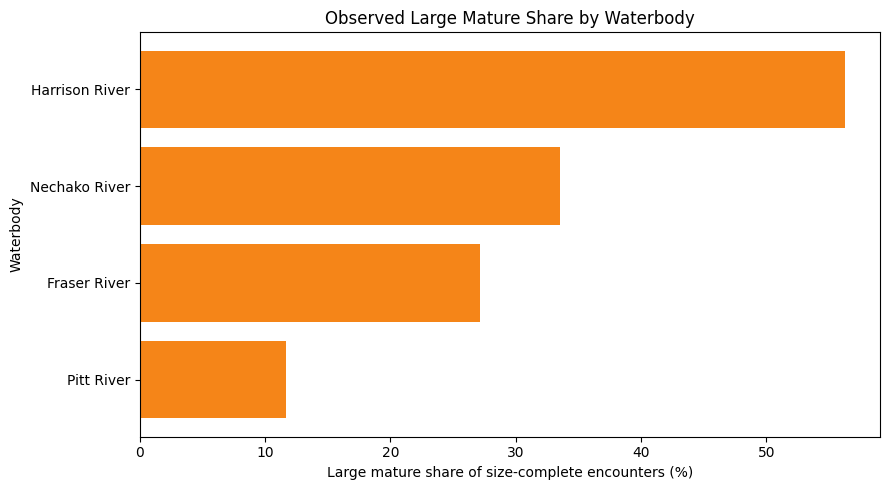

,encounters,fork_complete,median_fork_length,large_count,large_share_percent,fork_complete_percent
waterbody,,,,,,
Harrison River,12792,12725,155.00,7160,56.30,99.50
Nechako River,2749,1556,75.10,522,33.50,56.60
Fraser River,158571,157731,115.00,42790,27.10,99.50
Pitt River,2644,2636,100.00,307,11.60,99.70


In [23]:

reliable_waterbodies = (
    waterbody_summary[waterbody_summary["fork_complete"] >= 100]
    .sort_values("large_share_percent", ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(reliable_waterbodies.index, reliable_waterbodies["large_share_percent"], color=ORANGE)
plt.xlabel("Large mature share of size-complete encounters (%)")
plt.ylabel("Waterbody")
plt.title("Observed Large Mature Share by Waterbody")
plt.tight_layout()
plt.show()

display(
    reliable_waterbodies[
        [
            "encounters", "fork_complete", "median_fork_length",
            "large_count", "large_share_percent", "fork_complete_percent"
        ]
    ].sort_values("large_share_percent", ascending=False).round(1)
)



Among the well-represented waterbodies, the Harrison River has the highest observed large mature share at about 56%. The Fraser River has a lower share of about 27%, but it contributes the largest absolute number of large mature encounters because it has much more data. The Nechako River requires extra caution because only about 57% of its encounter records have a usable fork length.

This comparison already supports Option C more directly than the other strategies. The size outcome is well defined, and the recorded share changes substantially by waterbody.



## High-rate waterbody-RKM segments

For a more detailed comparison, I keep segments with at least 100 size-complete encounters and at least 80% fork length completeness. These rules reduce the risk that a segment appears strong because of a tiny or highly incomplete sample.


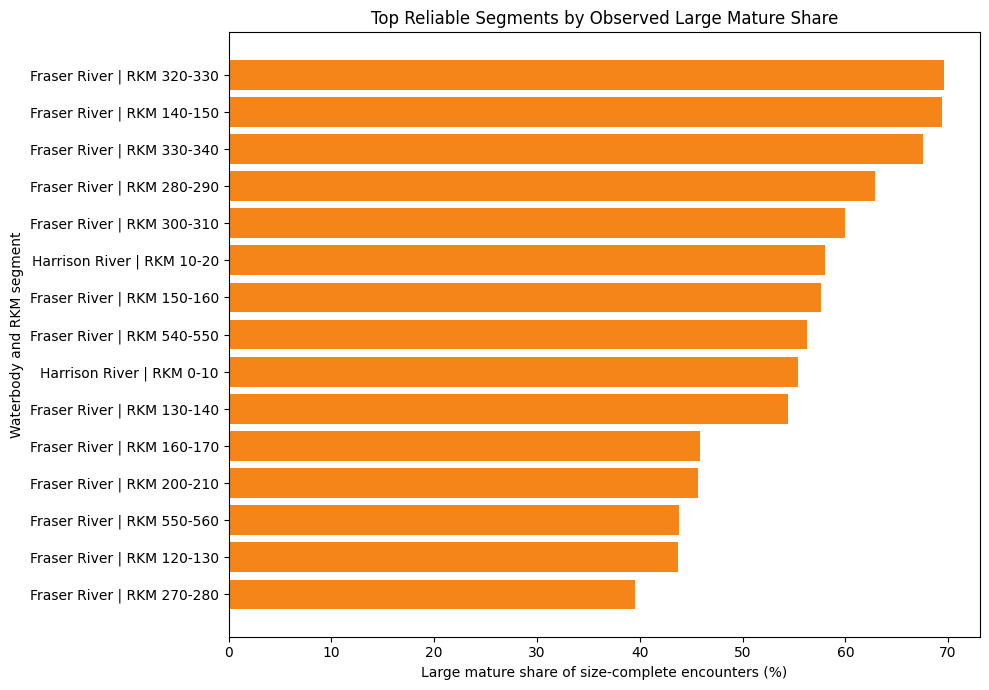

,waterbody,rkm_round,encounters,fork_complete,large_count,large_share_percent,median_fork_length,fork_complete_percent
0,Fraser River,320-330,1483,1478,1029,69.60,180.00,99.70
1,Fraser River,140-150,2584,2582,1792,69.40,179.00,99.90
2,Fraser River,330-340,2640,2626,1773,67.50,174.00,99.50
3,Fraser River,280-290,161,159,100,62.90,167.00,98.80
4,Fraser River,300-310,281,280,168,60.00,172.50,99.60
5,Harrison River,10-20,4299,4285,2485,58.00,157.00,99.70
6,Fraser River,150-160,1772,1766,1018,57.60,161.00,99.70
7,Fraser River,540-550,243,238,134,56.30,163.50,97.90
8,Harrison River,0-10,8493,8440,4675,55.40,154.00,99.40
9,Fraser River,130-140,2586,2573,1400,54.40,156.00,99.50


In [24]:

reliable_segments = (
    segment_summary.reset_index()
    .dropna(subset=["rkm_round"])
    .query("fork_complete >= 100 and fork_complete_percent >= 80")
    .sort_values(["large_share_percent", "large_count"], ascending=False)
    .copy()
)

reliable_segments["segment"] = (
    reliable_segments["waterbody"] + " | RKM " + reliable_segments["rkm_round"]
)

top_rate_segments = reliable_segments.head(15).copy()
plot_c_rate = top_rate_segments.sort_values("large_share_percent", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_c_rate["segment"], plot_c_rate["large_share_percent"], color=ORANGE)
plt.xlabel("Large mature share of size-complete encounters (%)")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top Reliable Segments by Observed Large Mature Share")
plt.tight_layout()
plt.show()

display(
    top_rate_segments[
        [
            "waterbody", "rkm_round", "encounters", "fork_complete",
            "large_count", "large_share_percent", "median_fork_length",
            "fork_complete_percent"
        ]
    ].reset_index(drop=True).round(1)
)



Several Fraser River segments have both a large sample and a high observed share. RKM 320-330, 140-150, and 330-340 each have large mature shares close to 68% to 70%. Harrison River RKM 0-10 and 10-20 also show high shares and thousands of large mature encounters.

These segments are more convincing than tiny segments with one or two fish because the pattern is supported by hundreds or thousands of size-complete encounters. They provide a clear starting point for the Phase 2 classifier and for a stakeholder discussion about targeted monitoring.



## Segments with the largest absolute number of large mature encounters

A high share and a high count answer different questions. The share is closer to monitoring efficiency, while the count shows where the current dataset has repeatedly documented large fish. I compare the largest counts so that I do not select a segment only because its denominator is smaller.


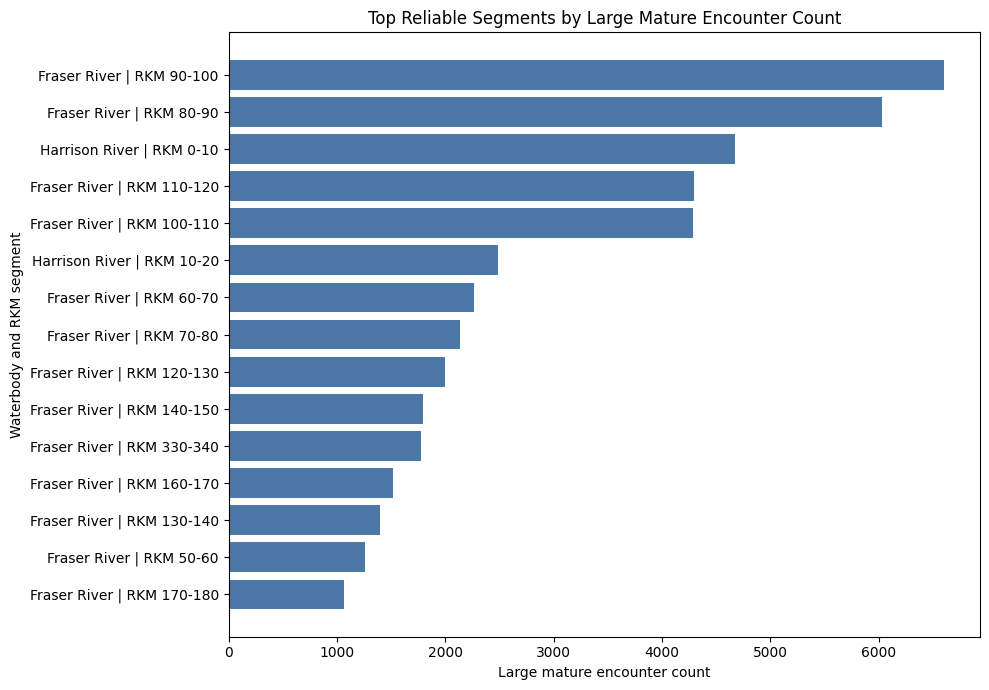

,waterbody,rkm_round,fork_complete,large_count,large_share_percent
0,Fraser River,90-100,29574,6605,22.30
1,Fraser River,80-90,27778,6032,21.70
2,Harrison River,0-10,8440,4675,55.40
3,Fraser River,110-120,11152,4296,38.50
4,Fraser River,100-110,12685,4286,33.80
5,Harrison River,10-20,4285,2485,58.00
6,Fraser River,60-70,10536,2269,21.50
7,Fraser River,70-80,14874,2135,14.40
8,Fraser River,120-130,4579,2000,43.70
9,Fraser River,140-150,2582,1792,69.40


In [25]:

top_count_segments = (
    reliable_segments
    .sort_values(["large_count", "large_share_percent"], ascending=False)
    .head(15)
    .copy()
)

plot_c_count = top_count_segments.sort_values("large_count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_c_count["segment"], plot_c_count["large_count"], color=BLUE)
plt.xlabel("Large mature encounter count")
plt.ylabel("Waterbody and RKM segment")
plt.title("Top Reliable Segments by Large Mature Encounter Count")
plt.tight_layout()
plt.show()

display(
    top_count_segments[
        [
            "waterbody", "rkm_round", "fork_complete",
            "large_count", "large_share_percent"
        ]
    ].reset_index(drop=True).round(1)
)


Fraser River RKM 90-100 and 80-90 have the largest absolute number of large mature encounter records, although their large mature shares are lower than the highest-rate segments. Harrison River RKM 0-10 combines a high count with a high share. This difference shows why the final decision should not rely on a single ranking.

For Option C, I carry forward a small set of EDA priority candidates rather than simply choosing the segments with the most captures. The strongest rate-based candidates are Fraser River RKM 140-150, 320-330, and 330-340. Harrison River RKM 0-10 and 10-20 are also important because they combine a high observed large mature share with substantial sample size. Phase 2 will test whether these patterns continue when I predict encounters from fish that were held out of model training.

This is still a ranking of patterns inside the recorded capture data. It does not show that these locations have the highest true encounter probability per hour of monitoring because the dataset does not contain survey effort or unsuccessful sampling attempts.



---

# 8. Strategy Decision

I summarize the evidence in one table. The support level is based on what the supplied dataset can answer, not on whether a strategy might be useful with additional data.


In [26]:

strategy_comparison = pd.DataFrame({
    "option": [
        "Option A: More even monitoring",
        "Option B: Hatchery-focused monitoring",
        "Option C: Large mature fish locations"
    ],
    "what_the_data_supports": [
        "The records are highly concentrated by waterbody and RKM segment.",
        "Confirmed hatchery encounters are strongly concentrated in the Nechako River.",
        "Fork length is available for a large majority of capture encounters, and large mature shares differ clearly by location."
    ],
    "main_limitation": [
        "No survey-effort denominator, cost, or unsuccessful survey information.",
        "Blank status is not an explicit wild label, and the confirmed records are narrow in coverage.",
        "Observed records still reflect historical effort and cannot estimate population abundance."
    ],
    "final_assessment": [
        "Partial support only",
        "Useful for a narrow hatchery objective",
        "Strongest support for the stated project"
    ]
})

display(strategy_comparison)


,option,what_the_data_supports,main_limitation,final_assessment
0,Option A: More even monitoring,The records are highly concentrated by waterbo...,"No survey-effort denominator, cost, or unsucce...",Partial support only
1,Option B: Hatchery-focused monitoring,Confirmed hatchery encounters are strongly con...,"Blank status is not an explicit wild label, an...",Useful for a narrow hatchery objective
2,Option C: Large mature fish locations,Fork length is available for a large majority ...,Observed records still reflect historical effo...,Strongest support for the stated project


Based on the EDA, I recommend continuing with **Option C**. It is the only option that connects a clearly defined outcome to a field with broad usable coverage. The data identifies meaningful differences across waterbodies and RKM segments, and these differences can be developed into a supervised classification problem.

The EDA gives me a concrete set of locations to test in Phase 2. The main high-priority candidates are Fraser River RKM 140-150, 320-330, and 330-340, together with Harrison River RKM 0-10 and 10-20. I do not treat this list as the final recommendation yet. Instead, I use the model and held-out data to check whether the same locations remain strong after time and location information are considered together.

The central limitation remains unchanged. A high observed share in this file is not the same as high monitoring efficiency. These are historical capture records, and the file does not contain a denominator for survey effort. My final recommendation will therefore describe locations and conditions associated with recorded large mature encounters, not estimated fish abundance or expected captures per unit of effort.


---

# 9. Phase 2: Supervised Classification

## Build the modeling table and target

The Phase 2 question has a predefined outcome, so I treat it as a supervised binary classification problem. One encounter is the observation unit. The positive class is `large_mature = 1` when fork length is at least 150 cm, and the negative class is `0` when fork length is below 150 cm.

I require a usable fork length, waterbody, RKM segment, capture month, and capture year. I do not fill a missing fork length because that value determines the target itself. I also create a combined waterbody-RKM location label. The combination is important because a segment such as RKM 10-20 has a different geographic meaning in different rivers.


In [27]:
model_data = encounters.dropna(
    subset=[
        "fork_length", "waterbody", "rkm_round", "rkm_midpoint",
        "capture_month", "capture_year"
    ]
).copy()

model_data["large_mature"] = (model_data["fork_length"] >= 150).astype(int)
model_data["location_segment"] = (
    model_data["waterbody"].astype(str) + " | " + model_data["rkm_round"].astype(str)
)

model_data["month_sin"] = np.sin(2 * np.pi * model_data["capture_month"] / 12)
model_data["month_cos"] = np.cos(2 * np.pi * model_data["capture_month"] / 12)

model_readiness = pd.DataFrame({
    "measure": [
        "Encounter rows ready for modeling",
        "Unique fish in modeling data",
        "Large mature encounters",
        "Large mature class percentage",
        "Distinct waterbody-RKM locations"
    ],
    "value": [
        f"{len(model_data):,}",
        f"{model_data['fish_id'].nunique():,}",
        f"{model_data['large_mature'].sum():,}",
        f"{model_data['large_mature'].mean() * 100:.1f}%",
        f"{model_data['location_segment'].nunique():,}"
    ]
})

display(model_readiness)


,measure,value
0,Encounter rows ready for modeling,"174,471"
1,Unique fish in modeling data,"85,895"
2,Large mature encounters,"50,728"
3,Large mature class percentage,29.1%
4,Distinct waterbody-RKM locations,115


The modeling table contains about 174,000 size-complete encounters and about 86,000 unique fish. Approximately 29% of the encounters are in the large mature class. This imbalance is noticeable but not extreme. It is still important because a model could obtain a fairly high accuracy by predicting the smaller class often, so I will not use accuracy as the only evaluation measure.

I represent month with sine and cosine features instead of treating December and January as far apart numerically. This preserves the circular structure of the calendar. I keep capture year as a separate historical feature because the volume and composition of the database changed substantially across the study period.


## Feature choices and leakage control

The main model uses information that can support a decision about where and when to monitor. I include the combined waterbody-RKM segment, capture month, and capture year. I exclude fish ID and tag number because they are identifiers rather than useful general predictors. I also exclude fork length because it defines the target.

I exclude girth from the main model even though it would probably make prediction easier. Girth is another direct measurement of body size taken after a fish is captured. A model that depends on girth would not help the program decide where to monitor before the encounter occurs.

I also leave the incomplete hatchery flag out of the main model. The field confirms some hatchery fish, but a blank value is not a reliable wild category. More importantly, hatchery status may not be known before capture. I test it later as a sensitivity check to see whether excluding it materially changes model performance.


In [28]:
feature_plan = pd.DataFrame({
    "field": [
        "waterbody + rkm_round", "capture_month", "capture_year",
        "hatchery_confirmed", "fish_id", "tag_number", "fork_length", "girth"
    ],
    "model_use": [
        "Main categorical location feature",
        "Main seasonal feature using sine and cosine",
        "Main historical time feature",
        "Sensitivity check only",
        "Group train/test split only, never a predictor",
        "Excluded identifier",
        "Defines the target, never a predictor",
        "Excluded direct body-size proxy"
    ],
    "reason": [
        "The same RKM number means different places in different waterbodies.",
        "Season may be associated with the recorded large mature encounter pattern.",
        "Survey and database patterns change across years.",
        "The field is incomplete and may not be known before capture.",
        "Using it as a predictor could allow the model to memorize individual fish.",
        "Tag labels do not generalize to new encounters.",
        "Including it would leak the answer into the model.",
        "It would answer fish size after capture rather than where to monitor."
    ]
})

display(feature_plan)


,field,model_use,reason
0,waterbody + rkm_round,Main categorical location feature,The same RKM number means different places in ...
1,capture_month,Main seasonal feature using sine and cosine,Season may be associated with the recorded lar...
2,capture_year,Main historical time feature,Survey and database patterns change across years.
3,hatchery_confirmed,Sensitivity check only,The field is incomplete and may not be known b...
4,fish_id,"Group train/test split only, never a predictor",Using it as a predictor could allow the model ...
5,tag_number,Excluded identifier,Tag labels do not generalize to new encounters.
6,fork_length,"Defines the target, never a predictor",Including it would leak the answer into the mo...
7,girth,Excluded direct body-size proxy,It would answer fish size after capture rather...


## Group-aware train and test split

The same fish can appear in several encounters. A normal random row split could place one encounter from a fish in the training data and another encounter from the same fish in the test data. That would make the evaluation less convincing because the model would be tested partly on fish it had already seen.

I therefore split the data by `fish_id`. I use 80% of the fish groups for training and 20% for testing. The test set is left untouched while I fit the models and tune the decision tree. This makes the main evaluation closer to the question of whether the learned location and time patterns generalize to different fish.


In [29]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(
        model_data,
        model_data["large_mature"],
        groups=model_data["fish_id"]
    )
)

train_data = model_data.iloc[train_index].copy()
test_data = model_data.iloc[test_index].copy()

fish_overlap = len(
    set(train_data["fish_id"]).intersection(set(test_data["fish_id"]))
)

split_summary = pd.DataFrame({
    "set": ["Training", "Test"],
    "encounters": [len(train_data), len(test_data)],
    "unique_fish": [train_data["fish_id"].nunique(), test_data["fish_id"].nunique()],
    "large_mature_percent": [
        train_data["large_mature"].mean() * 100,
        test_data["large_mature"].mean() * 100
    ]
})

display(split_summary.round(2))
print(f"Fish appearing in both sets: {fish_overlap}")


,set,encounters,unique_fish,large_mature_percent
0,Training,139389,68716,28.89
1,Test,35082,17179,29.82


Fish appearing in both sets: 0


The split produces about 139,000 training encounters and 35,000 test encounters, with no fish appearing in both sets. The large mature share is also similar in the two sets, so the held-out sample still represents the overall classification problem reasonably well.

This split does not remove all historical sampling bias. It only prevents direct fish-level leakage. The test rows are still historical encounters from the same monitoring system, which is why I later add a separate time-based robustness check.


## Prepare the feature matrix

The location feature is categorical, so I one-hot encode it rather than assigning arbitrary integers to river segments. I define the categories using the training data only. Locations with fewer than 100 training encounters are grouped into `Other / sparse segment`. This reduces the chance that the model creates a strong rule from a location represented by only a few observations.

I use Fraser River RKM 90-100 as the reference location for logistic regression because it is one of the largest and most stable encounter groups in the dataset. This gives the later location coefficients a concrete comparison. I standardize capture year and the two month features using the training data, then apply the same transformation to the test data.


In [30]:
location_counts = train_data["location_segment"].value_counts()
common_locations = location_counts[location_counts >= 100].index.tolist()

reference_location = "Fraser River | 90-100"

location_categories = [reference_location] + sorted([
    location for location in common_locations
    if location != reference_location
]) + ["Other / sparse segment"]

for data in [train_data, test_data]:
    data["location_model"] = data["location_segment"].where(
        data["location_segment"].isin(common_locations),
        "Other / sparse segment"
    )
    data["location_model"] = pd.Categorical(
        data["location_model"],
        categories=location_categories
    )

train_location = pd.get_dummies(
    train_data["location_model"],
    prefix="location",
    drop_first=True,
    dtype=int
)

test_location = pd.get_dummies(
    test_data["location_model"],
    prefix="location",
    drop_first=True,
    dtype=int
).reindex(columns=train_location.columns, fill_value=0)

numeric_features = ["capture_year", "month_sin", "month_cos"]

scaler = StandardScaler()
train_numeric = scaler.fit_transform(train_data[numeric_features])
test_numeric = scaler.transform(test_data[numeric_features])

X_train = hstack([
    csr_matrix(train_numeric),
    csr_matrix(train_location.to_numpy())
]).tocsr()

X_test = hstack([
    csr_matrix(test_numeric),
    csr_matrix(test_location.to_numpy())
]).tocsr()

y_train = train_data["large_mature"].to_numpy()
y_test = test_data["large_mature"].to_numpy()

feature_names = numeric_features + train_location.columns.tolist()

print(f"Frequent location categories kept: {len(common_locations)}")
print(f"Final model features: {X_train.shape[1]}")
print(f"Reference location: {reference_location}")


Frequent location categories kept: 38
Final model features: 41
Reference location: Fraser River | 90-100


The final feature matrix is intentionally small enough to inspect. It uses the information that is most closely tied to the stakeholder's question rather than adding every available field. This also makes the comparison between logistic regression and a decision tree easier to explain.

The `Other / sparse segment` group is not meant to say that all rare locations are ecologically similar. It is a modeling safeguard. I do not use that grouped category to make a final site recommendation.


## Majority-class baseline

Before fitting a real classifier, I calculate a simple baseline that predicts every test encounter as not large mature. This is intentionally weak, but it shows why accuracy alone can be misleading when the classes are not balanced.


In [31]:
def metric_row(model_name, y_true, predicted, probability):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predicted),
        "precision": precision_score(y_true, predicted, zero_division=0),
        "recall": recall_score(y_true, predicted, zero_division=0),
        "f1": f1_score(y_true, predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability)
    }

baseline_prediction = np.zeros(len(y_test), dtype=int)
baseline_probability = np.zeros(len(y_test), dtype=float)

baseline_metrics = metric_row(
    "Majority baseline",
    y_test,
    baseline_prediction,
    baseline_probability
)

baseline_confusion = pd.DataFrame(
    confusion_matrix(y_test, baseline_prediction),
    index=["Actual < 150 cm", "Actual >= 150 cm"],
    columns=["Predicted < 150 cm", "Predicted >= 150 cm"]
)

baseline_table = pd.DataFrame([baseline_metrics])
display(baseline_table.round(3))
display(baseline_confusion)


,model,accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.70,0.00,0.00,0.00,0.50


,Predicted < 150 cm,Predicted >= 150 cm
Actual < 150 cm,24619,0
Actual >= 150 cm,10463,0


The majority baseline reaches about 70% accuracy even though it never identifies a large mature encounter. Its recall and F1 score are both zero, and its ROC-AUC is 0.50. This confirms that a high-looking accuracy value can hide a useless classification rule.

For this project, recall matters because a false negative means the model misses an encounter that actually belongs to the large mature class. Precision also matters because too many false positives could direct attention toward less useful conditions. F1 provides one balance between these two errors, while ROC-AUC measures how well the model ranks positive encounters across possible classification thresholds.


## Logistic regression baseline

I begin with logistic regression because the target is binary and the model returns a probability between 0 and 1. It is also useful for this stakeholder because the location coefficients can be translated into odds ratios relative to a reference location.

I use the default 0.50 classification threshold for the main metric comparison. I do not treat 0.50 as a permanent operational rule. The program could later change the threshold depending on whether it is more costly to miss a promising location or to spend effort on a false positive.


In [32]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_probability = logistic_model.predict_proba(X_test)[:, 1]
logistic_prediction = (logistic_probability >= 0.50).astype(int)

logistic_metrics = metric_row(
    "Logistic regression",
    y_test,
    logistic_prediction,
    logistic_probability
)

logistic_confusion = pd.DataFrame(
    confusion_matrix(y_test, logistic_prediction),
    index=["Actual < 150 cm", "Actual >= 150 cm"],
    columns=["Predicted < 150 cm", "Predicted >= 150 cm"]
)

display(pd.DataFrame([logistic_metrics]).round(3))
display(logistic_confusion)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.74,0.62,0.29,0.40,0.72


,Predicted < 150 cm,Predicted >= 150 cm
Actual < 150 cm,22717,1902
Actual >= 150 cm,7372,3091


The logistic model improves meaningfully over the majority baseline. Its ROC-AUC is about 0.72, which means the location and time features contain useful discrimination for the large mature class. At the default threshold, precision is about 0.62 while recall is about 0.30. The model is therefore more conservative about predicting the positive class. When it predicts a large mature encounter it is often correct, but it still misses many actual large mature encounters.

This is important for the management interpretation. The model is better used as a probability and ranking tool than as an automatic yes-or-no rule. A program with a strong preference for not missing promising encounters could lower the threshold, but that would also increase the number of false positives.


## Check how RKM should be represented

I originally considered using RKM as a numeric midpoint. That representation assumes a fairly smooth relationship between river kilometer and the large mature outcome. The EDA suggests that the pattern is more local and irregular, with some specific segments standing out from nearby segments.

I therefore compare the main categorical waterbody-RKM representation with an alternative logistic regression that uses numeric RKM midpoint plus waterbody. I keep the same train and test fish so the comparison is fair.


In [33]:
waterbody_categories = sorted(train_data["waterbody"].astype(str).unique())

for data in [train_data, test_data]:
    data["waterbody_model"] = pd.Categorical(
        data["waterbody"].astype(str),
        categories=waterbody_categories
    )

train_waterbody = pd.get_dummies(
    train_data["waterbody_model"],
    prefix="waterbody",
    drop_first=True,
    dtype=int
)

test_waterbody = pd.get_dummies(
    test_data["waterbody_model"],
    prefix="waterbody",
    drop_first=True,
    dtype=int
).reindex(columns=train_waterbody.columns, fill_value=0)

numeric_rkm_features = [
    "capture_year", "month_sin", "month_cos", "rkm_midpoint"
]

rkm_scaler = StandardScaler()
train_rkm_numeric = rkm_scaler.fit_transform(train_data[numeric_rkm_features])
test_rkm_numeric = rkm_scaler.transform(test_data[numeric_rkm_features])

X_train_rkm = hstack([
    csr_matrix(train_rkm_numeric),
    csr_matrix(train_waterbody.to_numpy())
]).tocsr()

X_test_rkm = hstack([
    csr_matrix(test_rkm_numeric),
    csr_matrix(test_waterbody.to_numpy())
]).tocsr()

numeric_rkm_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

numeric_rkm_model.fit(X_train_rkm, y_train)

numeric_rkm_probability = numeric_rkm_model.predict_proba(X_test_rkm)[:, 1]
numeric_rkm_prediction = (numeric_rkm_probability >= 0.50).astype(int)

numeric_rkm_metrics = metric_row(
    "Logistic: numeric RKM",
    y_test,
    numeric_rkm_prediction,
    numeric_rkm_probability
)

rkm_comparison = pd.DataFrame([
    numeric_rkm_metrics,
    logistic_metrics
])

rkm_comparison.loc[
    rkm_comparison["model"].eq("Logistic regression"), "model"
] = "Logistic: categorical segment"

display(rkm_comparison.round(3))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic: numeric RKM,0.72,0.60,0.19,0.28,0.70
1,Logistic: categorical segment,0.74,0.62,0.29,0.40,0.72


The categorical segment model performs better. Its ROC-AUC is about 0.72 compared with about 0.70 for the numeric RKM version, and its F1 score is also clearly higher. I therefore keep the combined waterbody-RKM segment as the main location representation.

This result also makes sense for the decision problem. Managers need to identify specific reaches, and the categorical representation does not force the relationship to increase or decrease smoothly as RKM changes.


## Decision tree comparison and grouped depth selection

I next fit a decision tree because it can represent nonlinear combinations of location and time without requiring the same additive structure as logistic regression. A tree can also be followed as a sequence of decisions, which keeps it more interpretable than a much larger ensemble model.

Tree depth is a hyperparameter chosen before the final test evaluation. I compare a small set of depths with three-fold group cross-validation inside the training data. The folds are grouped by fish ID for the same leakage reason used in the main train-test split. I set `min_samples_leaf=100` so that a terminal rule must be supported by a meaningful number of training encounters rather than a handful of observations.


In [34]:
depth_results = []
group_cv = GroupKFold(n_splits=3)

for depth in [3, 5, 7, 10, 15]:
    fold_auc = []

    for cv_train_index, cv_valid_index in group_cv.split(
        X_train,
        y_train,
        groups=train_data["fish_id"].to_numpy()
    ):
        cv_tree = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=100,
            random_state=42
        )

        cv_tree.fit(X_train[cv_train_index], y_train[cv_train_index])
        cv_probability = cv_tree.predict_proba(X_train[cv_valid_index])[:, 1]

        fold_auc.append(
            roc_auc_score(y_train[cv_valid_index], cv_probability)
        )

    depth_results.append({
        "max_depth": depth,
        "mean_group_cv_auc": np.mean(fold_auc),
        "fold_1_auc": fold_auc[0],
        "fold_2_auc": fold_auc[1],
        "fold_3_auc": fold_auc[2]
    })

depth_results = pd.DataFrame(depth_results)
display(depth_results.round(3))

best_depth = int(
    depth_results.loc[
        depth_results["mean_group_cv_auc"].idxmax(),
        "max_depth"
    ]
)

print(f"Selected max_depth: {best_depth}")


,max_depth,mean_group_cv_auc,fold_1_auc,fold_2_auc,fold_3_auc
0,3,0.66,0.66,0.66,0.66
1,5,0.68,0.68,0.68,0.69
2,7,0.70,0.70,0.70,0.70
3,10,0.71,0.71,0.71,0.72
4,15,0.73,0.73,0.73,0.74


Selected max_depth: 15


The grouped validation score improves as the tree becomes deeper across the tested range, with depth 15 performing best among the candidates. I select depth 15 rather than fitting an unrestricted tree. This gives the model enough flexibility to represent location patterns while still placing a clear bound on complexity and requiring at least 100 training encounters in each leaf.

The depth search uses only the training set. The held-out test set remains reserved for the final comparison with logistic regression.


In [35]:
tree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=100,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_probability = tree_model.predict_proba(X_test)[:, 1]
tree_prediction = (tree_probability >= 0.50).astype(int)

tree_metrics = metric_row(
    "Decision tree",
    y_test,
    tree_prediction,
    tree_probability
)

tree_confusion = pd.DataFrame(
    confusion_matrix(y_test, tree_prediction),
    index=["Actual < 150 cm", "Actual >= 150 cm"],
    columns=["Predicted < 150 cm", "Predicted >= 150 cm"]
)

display(pd.DataFrame([tree_metrics]).round(3))
display(tree_confusion)


,model,accuracy,precision,recall,f1,roc_auc
0,Decision tree,0.74,0.66,0.27,0.38,0.73


,Predicted < 150 cm,Predicted >= 150 cm
Actual < 150 cm,23185,1434
Actual >= 150 cm,7644,2819


The decision tree has a slightly higher ROC-AUC, accuracy, and precision than logistic regression. However, its recall and F1 score at the default threshold are slightly lower. The difference between the two models is not large enough for me to choose only on one performance number.

For the stakeholder, I keep logistic regression as the primary interpretation model because the probability estimates and location odds ratios are easier to translate into a monitoring recommendation. I use the decision tree as a comparison model. If both models and the original EDA point toward the same locations, that agreement is more convincing than relying on one model family alone.


,model,accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.70,0.00,0.00,0.00,0.50
1,Logistic regression,0.74,0.62,0.29,0.40,0.72
2,Decision tree,0.74,0.66,0.27,0.38,0.73


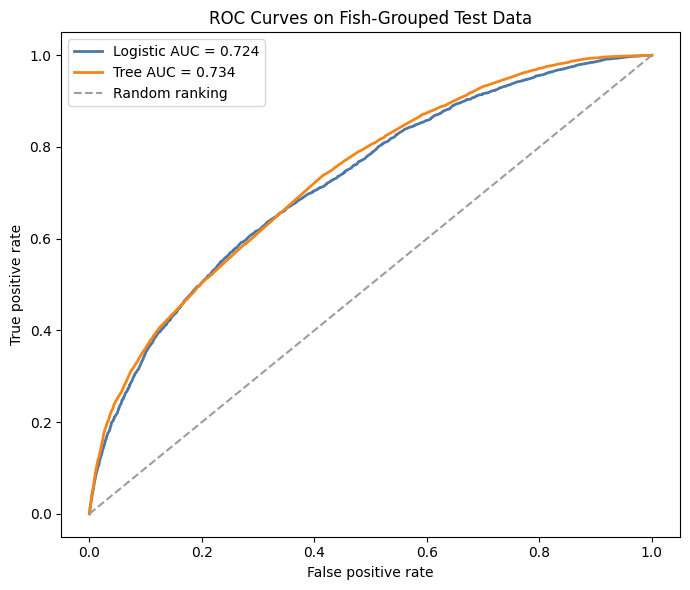

In [36]:
model_comparison = pd.DataFrame([
    baseline_metrics,
    logistic_metrics,
    tree_metrics
])

display(model_comparison.round(3))

log_fpr, log_tpr, _ = roc_curve(y_test, logistic_probability)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probability)

plt.figure(figsize=(7, 6))
plt.plot(log_fpr, log_tpr, color=BLUE, linewidth=2, label=f"Logistic AUC = {logistic_metrics['roc_auc']:.3f}")
plt.plot(tree_fpr, tree_tpr, color=ORANGE, linewidth=2, label=f"Tree AUC = {tree_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], color=GRAY, linestyle="--", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curves on Fish-Grouped Test Data")
plt.legend()
plt.tight_layout()
plt.show()


The ROC curves show that both trained models rank encounters better than random across a range of thresholds. The tree has a small AUC advantage, but logistic regression remains competitive and gives me a more direct way to explain how the location categories relate to the outcome.

I therefore do not interpret the tree's small AUC advantage as evidence that the logistic model is wrong. The two models make different simplifications of the same historical data. I use their agreement and disagreement as part of the final interpretation.


## Threshold sensitivity for logistic regression

The 0.50 cutoff is useful for a standard model comparison, but the monitoring decision may value recall differently from precision. I show several thresholds to make this trade-off visible. I do not select a new operational threshold from the test set because that would turn the held-out data into a tuning set.


In [37]:
threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60]:
    threshold_prediction = (logistic_probability >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_prediction, zero_division=0),
        "recall": recall_score(y_test, threshold_prediction, zero_division=0),
        "f1": f1_score(y_test, threshold_prediction, zero_division=0),
        "predicted_positive_percent": threshold_prediction.mean() * 100
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))


,threshold,precision,recall,f1,predicted_positive_percent
0,0.30,0.48,0.60,0.53,37.34
1,0.40,0.55,0.44,0.49,23.77
2,0.50,0.62,0.29,0.40,14.23
3,0.60,0.70,0.17,0.27,7.20


The trade-off is clear. Lowering the threshold increases recall because the model labels more encounters as potentially large mature, but precision falls because more of those positive predictions are false positives. At 0.30, recall is close to 0.60 and F1 is higher than at 0.50, but the model also flags a much larger share of encounters.

I keep 0.50 for the formal model comparison and use predicted probabilities for the location ranking. A final operational cutoff should be chosen only when the program can state the relative cost of extra monitoring effort compared with missing a promising location.


## Logistic location effects

To make the logistic model interpretable, I convert the fitted location coefficients into odds ratios. An odds ratio above 1 means that the model associates that segment with higher odds of a recorded large mature encounter than the reference location, Fraser River RKM 90-100, after the included month and year features are held constant.

I treat these as model associations, not causal effects. A high odds ratio does not prove that moving monitoring effort to that segment will cause more large fish to be captured. Historical effort and unmeasured environmental conditions are still missing from the dataset.


In [38]:
coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

coefficient_table["odds_ratio"] = np.exp(coefficient_table["coefficient"])

location_odds = coefficient_table[
    coefficient_table["feature"].str.startswith("location_")
].copy()

location_odds["location_segment"] = location_odds["feature"].str.replace(
    "location_", "", regex=False
)

location_odds = location_odds[
    ~location_odds["location_segment"].eq("Other / sparse segment")
].sort_values("odds_ratio", ascending=False)

location_odds_display = location_odds[
    ["location_segment", "coefficient", "odds_ratio"]
].head(15)

display(location_odds_display.round(3))


,location_segment,coefficient,odds_ratio
9,Fraser River | 140-150,1.78,5.94
22,Fraser River | 320-330,1.63,5.12
27,Fraser River | 540-550,1.63,5.11
23,Fraser River | 330-340,1.52,4.55
34,Harrison River | 10-20,1.42,4.15
33,Harrison River | 0-10,1.37,3.93
17,Fraser River | 280-290,1.35,3.87
20,Fraser River | 300-310,1.30,3.67
28,Fraser River | 550-560,1.21,3.37
8,Fraser River | 130-140,1.15,3.15


The largest positive location coefficients include the same Fraser River reaches that stood out in the EDA, especially RKM 140-150, 320-330, and 330-340. Harrison River RKM 0-10 and 10-20 also have clearly higher modeled odds than the Fraser River 90-100 reference.

I do not use the coefficient table by itself to make the final site recommendation. A coefficient can be high even when the supporting sample is smaller. The next step combines EDA sample size, held-out observed outcomes, and predictions from both models so the recommendation is based on several pieces of evidence at once.


## Sensitivity check for the incomplete hatchery flag

The EDA showed that the hatchery field is narrow and mostly blank. I excluded it from the main model because it is not a complete wild-versus-hatchery variable and may not be known before capture. I still test whether adding the confirmed hatchery indicator changes the main logistic result.


In [39]:
X_train_hatchery = hstack([
    X_train,
    csr_matrix(train_data[["hatchery_confirmed"]].astype(int).to_numpy())
]).tocsr()

X_test_hatchery = hstack([
    X_test,
    csr_matrix(test_data[["hatchery_confirmed"]].astype(int).to_numpy())
]).tocsr()

hatchery_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

hatchery_model.fit(X_train_hatchery, y_train)

hatchery_probability = hatchery_model.predict_proba(X_test_hatchery)[:, 1]
hatchery_prediction = (hatchery_probability >= 0.50).astype(int)

hatchery_metrics = metric_row(
    "Logistic + confirmed hatchery flag",
    y_test,
    hatchery_prediction,
    hatchery_probability
)

hatchery_comparison = pd.DataFrame([
    logistic_metrics,
    hatchery_metrics
])

display(hatchery_comparison.round(3))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.74,0.62,0.29,0.40,0.72
1,Logistic + confirmed hatchery flag,0.74,0.62,0.30,0.41,0.73


Adding the confirmed hatchery flag improves ROC-AUC only slightly, from about 0.724 to about 0.729. The improvement is too small to make this incomplete field central to the model. This sensitivity check supports the simpler main specification based on location and time.

This result also helps preserve the management focus. The main recommendation should be usable for planning a survey before the fish is captured, and location plus calendar information is more directly actionable than a post-capture status field.


---

# 10. Connecting the EDA, Model, and Monitoring Recommendation

## Do the high-priority EDA locations remain strong on held-out fish?

This section addresses the most important transition in the project. The EDA identified candidate locations from the full historical record, but the final recommendation should not stop there. I now ask whether those same locations also show strong outcomes in the fish-grouped test set and whether both fitted models assign them high probabilities.

I only display locations that passed the earlier EDA reliability rules and that also contain at least 100 held-out test encounters. This removes small locations from the final ranking even if they have a high coefficient or a high predicted probability.


In [40]:
test_results = test_data[
    ["waterbody", "rkm_round", "capture_month", "large_mature"]
].copy()

test_results["logistic_probability"] = logistic_probability
test_results["tree_probability"] = tree_probability

held_out_segments = (
    test_results.groupby(["waterbody", "rkm_round"])
    .agg(
        held_out_encounters=("large_mature", "size"),
        held_out_observed_large_percent=("large_mature", lambda values: values.mean() * 100),
        logistic_mean_probability_percent=("logistic_probability", lambda values: values.mean() * 100),
        tree_mean_probability_percent=("tree_probability", lambda values: values.mean() * 100)
    )
    .reset_index()
)

eda_reliable = reliable_segments[
    [
        "waterbody", "rkm_round", "fork_complete", "large_count",
        "large_share_percent", "fork_complete_percent"
    ]
].copy()

priority_locations = eda_reliable.merge(
    held_out_segments,
    on=["waterbody", "rkm_round"],
    how="inner"
)

priority_locations = priority_locations[
    priority_locations["held_out_encounters"] >= 100
].copy()

priority_locations["location"] = (
    priority_locations["waterbody"] + " | RKM " + priority_locations["rkm_round"]
)

priority_locations = priority_locations.sort_values(
    ["logistic_mean_probability_percent", "held_out_encounters"],
    ascending=[False, False]
)

priority_display = priority_locations[
    [
        "location", "fork_complete", "large_share_percent",
        "held_out_encounters", "held_out_observed_large_percent",
        "logistic_mean_probability_percent", "tree_mean_probability_percent"
    ]
].head(12)

display(priority_display.round(1))


,location,fork_complete,large_share_percent,held_out_encounters,held_out_observed_large_percent,logistic_mean_probability_percent,tree_mean_probability_percent
0,Fraser River | RKM 320-330,1478,69.60,328,72.30,69.70,67.50
1,Fraser River | RKM 140-150,2582,69.40,487,67.80,69.10,67.30
2,Fraser River | RKM 330-340,2626,67.50,566,68.20,67.10,65.40
5,Harrison River | RKM 10-20,4285,58.00,889,58.90,58.20,57.20
6,Fraser River | RKM 150-160,1766,57.60,361,59.80,57.50,54.60
8,Harrison River | RKM 0-10,8440,55.40,1711,56.20,55.30,55.70
9,Fraser River | RKM 130-140,2573,54.40,518,59.30,52.40,48.00
10,Fraser River | RKM 160-170,3303,45.90,667,44.70,47.00,43.70
13,Fraser River | RKM 120-130,4579,43.70,870,44.60,43.40,42.90
16,Fraser River | RKM 110-120,11152,38.50,2239,41.30,37.90,36.90


The EDA-to-model connection is strong for several locations. Fraser River RKM 320-330, 140-150, and 330-340 remain at the top of the held-out ranking. Their full-data EDA large mature shares are roughly 68% to 70%, their held-out observed shares are also around 68% to 72%, and both models assign high average probabilities. This is the clearest convergence in the project.

Harrison River RKM 10-20 and 0-10 also remain strong. Their modeled probabilities are lower than the three top Fraser reaches but still well above many common Fraser segments, and they have much larger supporting samples than many high-rate locations. Fraser River RKM 150-160 and 130-140 are reasonable secondary candidates because their held-out observed shares and model probabilities remain elevated.

The final location recommendation is therefore more specific than the EDA alone. I would treat Fraser River RKM 140-150, 320-330, and 330-340 as the strongest candidate reaches for Option C, with Harrison River RKM 0-10 and 10-20 as high-support additional priorities. These are places where the descriptive EDA, held-out observations, and two different model families point in the same direction.

I still describe them as **candidate monitoring priorities based on recorded encounter patterns**. The dataset cannot show that these reaches produce more large mature fish per hour, per net, or per dollar because survey effort is not recorded.


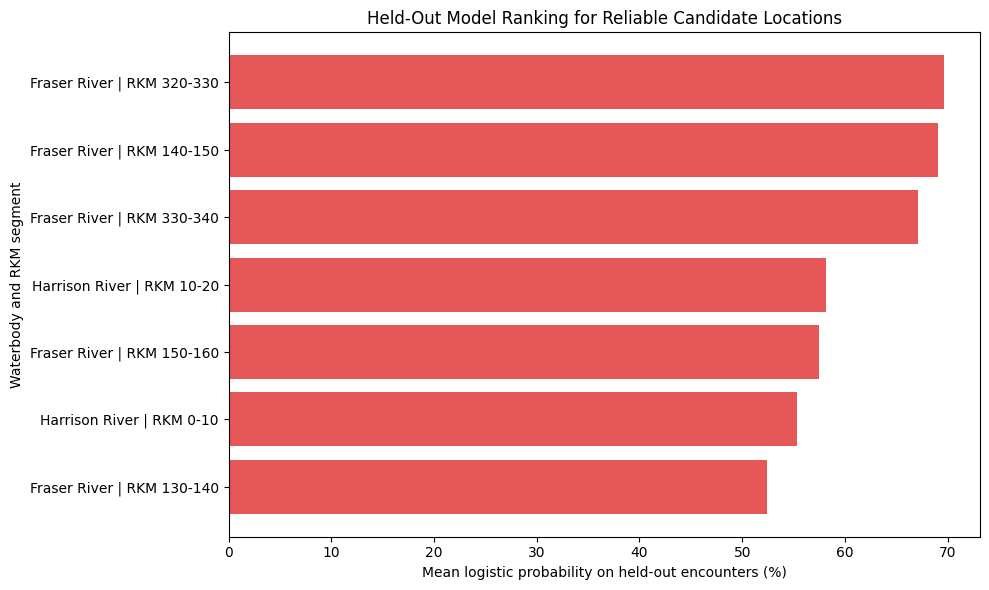

In [41]:
plot_priority = priority_display.head(7).sort_values(
    "logistic_mean_probability_percent",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_priority["location"],
    plot_priority["logistic_mean_probability_percent"],
    color=RED
)
plt.xlabel("Mean logistic probability on held-out encounters (%)")
plt.ylabel("Waterbody and RKM segment")
plt.title("Held-Out Model Ranking for Reliable Candidate Locations")
plt.tight_layout()
plt.show()


The held-out probability plot gives a direct presentation-ready link from the modeling stage to the management question. It does not rank locations by the number of historical captures. It ranks the model's estimated large mature probability among encounters that actually occurred in the held-out sample, while the table beside it preserves sample size and observed outcome information.


## Capture month pattern

The proposal asks for locations and conditions associated with large mature encounters. The dataset does not contain water temperature, river flow, depth, gear, or survey effort, so the main condition I can use responsibly is capture timing. I summarize the held-out results by month and compare the observed large mature share with the average model probability.


,capture_month,held_out_encounters,observed_large_percent,logistic_mean_probability_percent,tree_mean_probability_percent
0,1,709,10.70,16.40,13.00
1,2,773,14.10,15.40,14.10
2,3,1281,20.10,16.90,18.00
3,4,2582,21.30,17.40,20.80
4,5,1769,23.10,22.00,23.50
5,6,1731,28.40,29.20,27.40
6,7,2967,31.60,33.10,30.20
7,8,4427,37.30,37.10,35.70
8,9,6558,35.80,33.80,34.80
9,10,7676,31.60,31.00,31.30


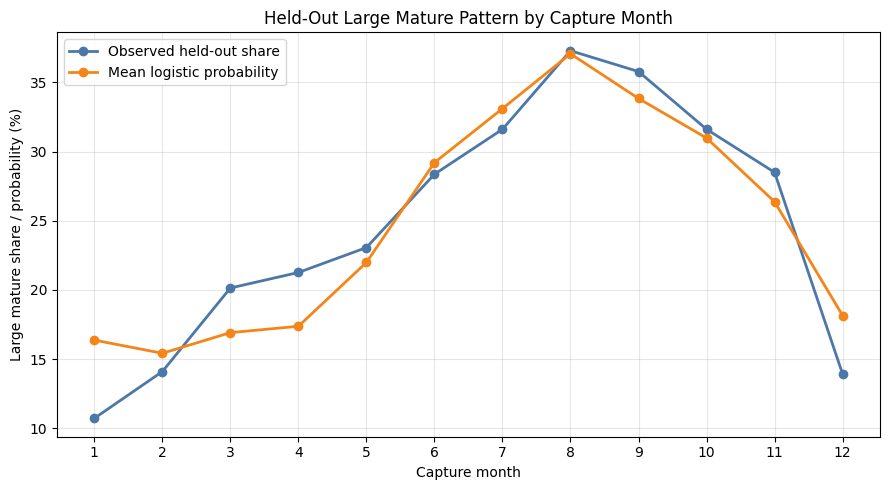

In [42]:
month_results = (
    test_results.groupby("capture_month")
    .agg(
        held_out_encounters=("large_mature", "size"),
        observed_large_percent=("large_mature", lambda values: values.mean() * 100),
        logistic_mean_probability_percent=("logistic_probability", lambda values: values.mean() * 100),
        tree_mean_probability_percent=("tree_probability", lambda values: values.mean() * 100)
    )
    .reset_index()
)

display(month_results.round(1))

plt.figure(figsize=(9, 5))
plt.plot(
    month_results["capture_month"],
    month_results["observed_large_percent"],
    color=BLUE,
    marker="o",
    linewidth=2,
    label="Observed held-out share"
)
plt.plot(
    month_results["capture_month"],
    month_results["logistic_mean_probability_percent"],
    color=ORANGE,
    marker="o",
    linewidth=2,
    label="Mean logistic probability"
)
plt.xticks(range(1, 13))
plt.xlabel("Capture month")
plt.ylabel("Large mature share / probability (%)")
plt.title("Held-Out Large Mature Pattern by Capture Month")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The held-out pattern is strongest in late summer. August has the highest observed large mature share at about 37%, followed by September at about 36%. The logistic model follows the same broad shape, with higher probabilities from roughly July through October and lower probabilities in winter and early spring.

I interpret month as a historical association rather than a direct biological mechanism. The database does not tell me how much survey effort occurred in each month. A higher August or September share could reflect fish movement, survey design, location mix, gear, or several factors together. For planning, it is reasonable to describe late summer and early fall as conditions associated with more large mature records in this dataset, but not as proven optimal survey months per unit of effort.


## Location and month combinations

I combine location and month to make the recommendation more practical. I require at least 50 held-out encounters in a location-month combination so that the table is not dominated by very small cells. The ranking uses the mean logistic probability, while the observed held-out share remains visible as a reality check.


In [43]:
location_month_results = (
    test_results.groupby(["waterbody", "rkm_round", "capture_month"])
    .agg(
        held_out_encounters=("large_mature", "size"),
        observed_large_percent=("large_mature", lambda values: values.mean() * 100),
        logistic_mean_probability_percent=("logistic_probability", lambda values: values.mean() * 100)
    )
    .reset_index()
)

location_month_results = location_month_results[
    location_month_results["held_out_encounters"] >= 50
].copy()

location_month_results["location"] = (
    location_month_results["waterbody"] + " | RKM " + location_month_results["rkm_round"]
)

location_month_results = location_month_results.sort_values(
    "logistic_mean_probability_percent",
    ascending=False
)

display(
    location_month_results[
        [
            "location", "capture_month", "held_out_encounters",
            "observed_large_percent", "logistic_mean_probability_percent"
        ]
    ].head(15).round(1)
)


,location,capture_month,held_out_encounters,observed_large_percent,logistic_mean_probability_percent
77,Fraser River | RKM 140-150,9,93,68.80,73.30
78,Fraser River | RKM 140-150,10,65,67.70,71.90
194,Fraser River | RKM 320-330,7,76,77.60,71.10
195,Fraser River | RKM 320-330,8,108,76.90,70.90
76,Fraser River | RKM 140-150,8,126,66.70,70.80
196,Fraser River | RKM 320-330,9,56,73.20,70.60
204,Fraser River | RKM 330-340,8,233,75.10,70.50
75,Fraser River | RKM 140-150,7,50,54.00,68.60
205,Fraser River | RKM 330-340,9,83,57.80,68.10
193,Fraser River | RKM 320-330,6,60,56.70,67.20


The highest supported combinations are concentrated in the same three Fraser River priority reaches, especially during July through October. Fraser River RKM 140-150 is especially strong in August, September, and October. Fraser River RKM 320-330 is strong in July, August, and September, while RKM 330-340 is also strong during the summer and early fall. Harrison River 0-10 and 10-20 appear farther down the ranking but remain important because they have larger supporting samples in several months.

This gives the stakeholder a more concrete Phase 2 result: if Option C is pursued, the historical data most consistently points toward the three high-priority Fraser River reaches and the two Harrison River reaches, with late summer and early fall as the strongest recorded timing pattern. The recommendation should still be treated as a starting point for allocating or testing monitoring effort rather than as a guaranteed capture schedule.


---

# 11. Time-Based Robustness Check

The fish-grouped split is the main evaluation because it prevents individual fish from appearing in both training and testing. I also want to know whether the location and time pattern is only a result of mixing very old and newer records.

For this robustness check, I train on encounters through 2017 and test on encounters from 2018 to 2020. I remove any test fish that already appeared in the earlier training period. This is a stricter and smaller test because it combines a time boundary with fish-level separation. It is not used to tune the main models.


In [44]:
time_train = model_data[model_data["capture_year"] <= 2017].copy()
seen_fish = set(time_train["fish_id"])

time_test = model_data[
    (model_data["capture_year"] >= 2018) &
    (~model_data["fish_id"].isin(seen_fish))
].copy()

time_location_counts = time_train["location_segment"].value_counts()
time_common_locations = time_location_counts[
    time_location_counts >= 100
].index.tolist()

time_location_categories = [reference_location] + sorted([
    location for location in time_common_locations
    if location != reference_location
]) + ["Other / sparse segment"]

for data in [time_train, time_test]:
    data["location_model"] = data["location_segment"].where(
        data["location_segment"].isin(time_common_locations),
        "Other / sparse segment"
    )
    data["location_model"] = pd.Categorical(
        data["location_model"],
        categories=time_location_categories
    )

time_train_location = pd.get_dummies(
    time_train["location_model"],
    prefix="location",
    drop_first=True,
    dtype=int
)

time_test_location = pd.get_dummies(
    time_test["location_model"],
    prefix="location",
    drop_first=True,
    dtype=int
).reindex(columns=time_train_location.columns, fill_value=0)

time_scaler = StandardScaler()
time_train_numeric = time_scaler.fit_transform(time_train[numeric_features])
time_test_numeric = time_scaler.transform(time_test[numeric_features])

X_time_train = hstack([
    csr_matrix(time_train_numeric),
    csr_matrix(time_train_location.to_numpy())
]).tocsr()

X_time_test = hstack([
    csr_matrix(time_test_numeric),
    csr_matrix(time_test_location.to_numpy())
]).tocsr()

y_time_train = time_train["large_mature"].to_numpy()
y_time_test = time_test["large_mature"].to_numpy()

print(f"Earlier training encounters: {len(time_train):,}")
print(f"2018-2020 new-fish test encounters: {len(time_test):,}")
print(f"Fish overlap: {len(set(time_train['fish_id']).intersection(set(time_test['fish_id'])))}")


Earlier training encounters: 148,878
2018-2020 new-fish test encounters: 12,368
Fish overlap: 0


## Fit the models on the time-based split

After creating the earlier-period training set and the 2018-2020 new-fish test set, I fit the same logistic regression and decision tree specifications. I keep the 0.50 threshold for this robustness comparison so that the results can be compared with the main held-out evaluation. I do not use this later-period test to tune the models.

In [45]:
time_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)
time_logistic.fit(X_time_train, y_time_train)

time_logistic_probability = time_logistic.predict_proba(X_time_test)[:, 1]
time_logistic_prediction = (time_logistic_probability >= 0.50).astype(int)

time_logistic_metrics = metric_row(
    "Time holdout logistic",
    y_time_test,
    time_logistic_prediction,
    time_logistic_probability
)

time_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=100,
    random_state=42
)
time_tree.fit(X_time_train, y_time_train)

time_tree_probability = time_tree.predict_proba(X_time_test)[:, 1]
time_tree_prediction = (time_tree_probability >= 0.50).astype(int)

time_tree_metrics = metric_row(
    "Time holdout tree",
    y_time_test,
    time_tree_prediction,
    time_tree_probability
)

time_comparison = pd.DataFrame([
    time_logistic_metrics,
    time_tree_metrics
])

display(time_comparison.round(3))


,model,accuracy,precision,recall,f1,roc_auc
0,Time holdout logistic,0.79,0.56,0.65,0.60,0.82
1,Time holdout tree,0.80,0.60,0.51,0.55,0.80


The time-based check is encouraging. On fish first seen from 2018 to 2020, logistic regression reaches an ROC-AUC of about 0.82 and F1 of about 0.60. The decision tree also remains useful, with an ROC-AUC of about 0.79. In this later-period test, logistic regression performs better than the tree on both AUC and F1.

I do not interpret the higher late-period score as proof that the model will always improve in the future. The 2018 to 2020 test set has a different class balance, location mix, and survey history from the main group-held-out test. The important result is that the main location and time specification still has predictive signal under a stricter time boundary and does not depend only on seeing repeated fish.


---

# 12. Assumptions Log

| Assumption | How I handled it | Why it matters |
|---|---|---|
| A non-missing `capture_date` identifies a capture record. | I excluded release-only rows from encounter counts. | Release records would otherwise inflate apparent monitoring activity. |
| A blank hatchery field is not the same as an explicit wild label. | I use only a confirmed hatchery indicator and keep it out of the main model. | This avoids creating an unsupported wild category. |
| Multiple tag rows can represent one encounter. | I grouped by fish, date, waterbody, and RKM segment. | This prevents duplicate tag rows from becoming separate model examples. |
| Conflicting plausible fork lengths cannot be resolved from the file. | I set the encounter-level fork length to missing when more than one distinct value was recorded. | The target should not depend on an arbitrary measurement choice. |
| Fork lengths above 400 cm are data-entry problems. | I set the 23 extreme raw rows to missing while keeping the rest of the encounter. | This prevents clearly separated anomalies from becoming positive target labels. |
| Fork length >= 150 cm is the operational large mature class for this project. | I use the threshold exactly as defined by the client. | I do not independently claim that 150 cm proves biological maturity for every fish. |
| The same RKM label in different rivers is not the same location. | I combine waterbody and RKM segment for the main categorical feature. | This preserves the geographic meaning of the location. |
| Sparse locations should not drive the model. | Locations with fewer than 100 training encounters are grouped as `Other / sparse segment`. | This reduces unstable rules based on tiny samples. |
| Recaptured fish should not appear on both sides of the main evaluation. | I split train and test sets by `fish_id`. | This reduces leakage and gives a more credible test of generalization. |
| Capture month can represent a timing condition, but not monitoring effort. | I model month cyclically and interpret it as an association only. | Effort, gear, flow, and environmental variables are absent. |
| The 0.50 threshold is a comparison rule, not a final management cutoff. | I report threshold sensitivity and use probabilities for ranking. | The operational threshold should depend on the cost of false positives and false negatives. |
| Recorded encounters do not equal fish abundance or survey efficiency. | I describe observed and modeled associations and avoid population or per-effort claims. | The dataset contains captures but no survey-effort denominator. |


---

# 13. Limitations

The largest limitation remains the absence of survey effort. The dataset records successful captures and hatchery releases, but it does not record survey hours, number of crews, gear, unsuccessful attempts, or cost by location. Therefore, the model estimates the probability of the large mature class within the historical capture records. It does not estimate the probability of catching a large fish per unit of monitoring effort. This distinction is essential when I translate the model into a location recommendation.

The dataset is also observational and historical. Capture records span almost three decades, and the monitoring program, reporting practices, hatchery activity, fish movement, and gear may have changed. I include capture year and perform a later-period holdout, but those steps cannot fully remove changes in data collection. The B.C. catalogue also states that the dataset may not be verified and can change as new information becomes available.

Repeated fish are another source of dependence. The encounter construction removes repeated tag rows from the same event, and the main split keeps fish IDs separate between training and testing. However, fish that are repeatedly captured still contribute multiple encounters within one side of the split. The grouped validation reduces leakage but does not turn the data into a random sample of the sturgeon population.

The available predictors are limited. RKM is a coarse 10-km segment, and the file does not include river flow, water temperature, depth, exact sampling method, effort, or other environmental conditions. Capture month is therefore only a broad timing proxy. The model can identify where and when large mature encounters were more common in the recorded data, but it cannot explain the biological or operational mechanism behind those patterns.

The model performance is useful but not perfect. A group-held-out ROC-AUC around 0.72 to 0.73 shows real discrimination, but many individual encounters remain difficult to classify. The default 0.50 threshold also produces relatively low recall. For this reason, I use the model as a prioritization and comparison tool rather than as an automatic decision system. A real monitoring program should combine these results with field expertise, effort data, and operational constraints before changing survey allocation.


---

# 14. Executive Summary

The historical capture records give the strongest support to Option C, which focuses monitoring on locations and conditions associated with large mature White Sturgeon. Option A cannot be evaluated as a true efficiency strategy because the dataset records successful captures but does not contain survey effort, unsuccessful attempts, or cost. Option B provides useful information about confirmed hatchery encounters, especially in the Nechako River, but the hatchery field is incomplete and a blank value cannot be treated as a reliable wild label.

For Phase 2, I defined a large mature encounter as fork length greater than or equal to 150 cm. I trained a logistic regression model and a decision tree using waterbody-RKM location, capture month, and capture year. I separated training and testing by fish ID so the same fish did not appear on both sides of the main evaluation. Logistic regression reached an ROC-AUC of about 0.72 and the decision tree reached about 0.73 on the fish-grouped test set. The tree ranks encounters slightly better overall, but logistic regression is easier to interpret and has slightly better recall and F1 at the default threshold, so I use it as the main stakeholder model.

The most important result is the agreement between the EDA and the held-out model. Fraser River RKM 140-150, 320-330, and 330-340 consistently show the strongest supported large mature patterns. arrison River RKM 0-10 and 10-20 are also strong priorities with substantial supporting samples. The timing analysis shows that late summer and early fall, especially August and September, have the strongest recorded large mature pattern overall. Several of the highest-supported location-month combinations occur in the three priority Fraser reaches from roughly July through October.

My final recommendation is to use these reaches and timing patterns as candidate priorities for Option C monitoring or for a focused field trial. I would not describe them as proven to be the most efficient locations per hour or per dollar. The dataset does not contain monitoring effort, so it cannot separate fish availability from historical sampling intensity. A useful next step would be to collect effort information alongside future surveys and test whether these priority reaches actually improve large mature encounters per unit of monitoring effort.